In [ ]:
# %%capture
# !pip install --upgrade matplotlib numpy==1.26.0 # need refresh enviroment after installation

In [ ]:
# %%capture
# !pip install basemap phik sweetviz

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import phik

import numpy as np
import pandas as pd

import seaborn as sns
import sweetviz as sv
from matplotlib import pyplot as plt
from matplotlib.cbook import boxplot_stats
from mpl_toolkits.basemap import Basemap

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

%matplotlib inline

In [ ]:
sns.set_theme()

## Знакомство с данными

Набор данных состоит из 20 различных категориальных и непрерывных параметров 513 месторождений нефти.

In [ ]:
path = 'dataset_geologist.xlsx'
data = pd.read_excel(path, index_col='Unnamed: 0')

In [ ]:
new_col_names = ['_'.join(s.split()[1:]) for s in data.columns]
new_col_names[0] = 'num'

In [ ]:
data.columns = new_col_names

In [ ]:
data.head()

,num,Field_name,Reservoir_unit,Country,Region,Basin_name,Tectonic_regime,Latitude,Longitude,Operator_company,...,Hydrocarbon_type_(main),Reservoir_status_(current),Structural_setting,Depth_(top_reservoir_ft_TVD),Reservoir_period,Lithology_(main),Thickness_(gross_average_ft),Thickness_(net_pay_average_ft),Porosity_(matrix_average_%),Permeability_(air_average_mD)
0,6,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION,26.0800,49.8100,SAUDI ARAMCO,...,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
1,10,ABU GHARADIG,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.7422,28.4925,GUPCO,...,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10282,CRETACEOUS,SANDSTONE,745.0,144.0,10.0,8.0
2,11,ABU MADI-EL QARA,ABU MADI (LEVEL II),EGYPT,AFRICA,NILE DELTA,STRIKE-SLIP,31.4382,31.3616,IEOC,...,GAS,DECLINING PRODUCTION,WRENCH,9843,NEOGENE,THINLY-BEDDED SANDSTONE,115.0,66.0,22.0,200.0
3,12,ABU MADI-EL QARA,ABU MADI (LEVEL III),EGYPT,AFRICA,NILE DELTA,STRIKE-SLIP,31.4382,31.3616,IEOC,...,GAS,DECLINING PRODUCTION,WRENCH,10499,NEOGENE,SANDSTONE,509.0,410.0,20.0,300.0
4,20,AL HUWAISAH,SHUAIBA,OMAN,MIDDLE EAST,FAHUD SALT,COMPRESSION,21.9607,56.0452,PDO,...,OIL,REJUVENATING,SALT,4955,CRETACEOUS,LIMESTONE,250.0,100.0,21.0,60.0


In [ ]:
data.columns

Index(['num', 'Field_name', 'Reservoir_unit', 'Country', 'Region',
       'Basin_name', 'Tectonic_regime', 'Latitude', 'Longitude',
       'Operator_company', 'Onshore_or_offshore', 'Hydrocarbon_type_(main)',
       'Reservoir_status_(current)', 'Structural_setting',
       'Depth_(top_reservoir_ft_TVD)', 'Reservoir_period', 'Lithology_(main)',
       'Thickness_(gross_average_ft)', 'Thickness_(net_pay_average_ft)',
       'Porosity_(matrix_average_%)', 'Permeability_(air_average_mD)'],
      dtype='object')

In [ ]:
data.shape

(514, 21)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 513
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   num                             514 non-null    int64  
 1   Field_name                      514 non-null    object 
 2   Reservoir_unit                  514 non-null    object 
 3   Country                         514 non-null    object 
 4   Region                          514 non-null    object 
 5   Basin_name                      514 non-null    object 
 6   Tectonic_regime                 442 non-null    object 
 7   Latitude                        514 non-null    float64
 8   Longitude                       514 non-null    float64
 9   Operator_company                514 non-null    object 
 10  Onshore_or_offshore             514 non-null    object 
 11  Hydrocarbon_type_(main)         514 non-null    object 
 12  Reservoir_status_(current)      514 non-n

In [ ]:
data.dtypes

,0
num,int64
Field_name,object
Reservoir_unit,object
Country,object
Region,object
Basin_name,object
Tectonic_regime,object
Latitude,float64
Longitude,float64
Operator_company,object


In [ ]:
data.isna().sum()

,0
num,0
Field_name,0
Reservoir_unit,0
Country,0
Region,0
Basin_name,0
Tectonic_regime,72
Latitude,0
Longitude,0
Operator_company,0


In [ ]:
mask = data['Porosity_(matrix_average_%)'].isna()
train, test = data[~mask], data[mask]
train.shape, test.shape

((442, 21), (72, 21))

In [ ]:
df = train.copy()

In [ ]:
assert df.isna().sum().sum() == 0, 'В df остались пропуски!'

### Целевые переменные

**targets: Tectonic_regime, Porosity_(matrix_average_%)**

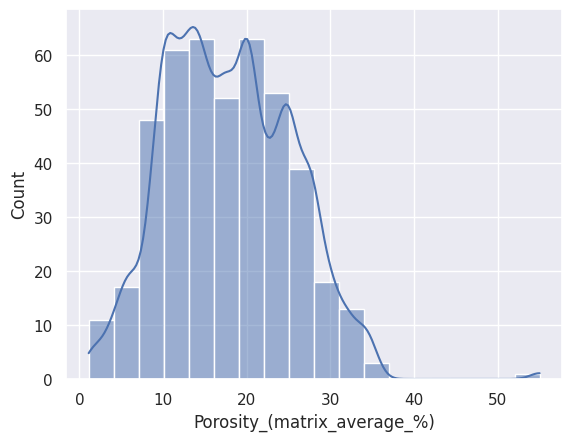

In [ ]:
sns.histplot(x=df['Porosity_(matrix_average_%)'], kde=True, kde_kws={'bw_adjust': 0.5});

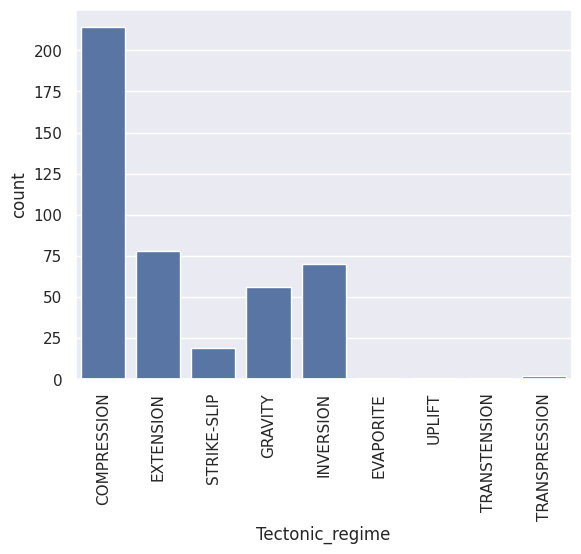

In [ ]:
sns.countplot(x=df['Tectonic_regime'])
plt.xticks(rotation=90);

In [ ]:
df['Tectonic_regime'].value_counts()

,count
Tectonic_regime,
COMPRESSION,214
EXTENSION,78
INVERSION,70
GRAVITY,56
STRIKE-SLIP,19
TRANSPRESSION,2
EVAPORITE,1
UPLIFT,1
TRANSTENSION,1


## Числовые признаки

In [ ]:
num_cols = df.select_dtypes(exclude='object')
num_cols.shape

(442, 8)

In [ ]:
num_cols.describe()

,num,Latitude,Longitude,Depth_(top_reservoir_ft_TVD),Thickness_(gross_average_ft),Thickness_(net_pay_average_ft),Porosity_(matrix_average_%),Permeability_(air_average_mD)
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,535.769231,35.078113,-8.349127,6613.658371,784.540724,189.061946,17.929955,469.916425
std,312.948093,21.861937,87.891701,3572.468358,1442.899648,282.161279,7.554253,1017.081304
min,6.000000,-38.398900,-151.615300,220.000000,11.000000,0.000000,1.100000,0.010000
25%,262.250000,28.124825,-102.403650,3824.500000,135.750000,43.000000,12.000000,10.000000
50%,521.500000,37.642350,2.247700,6137.500000,328.000000,100.000000,17.900000,79.500000
75%,805.000000,51.285650,57.562525,9071.500000,748.750000,206.500000,24.000000,400.000000
max,1071.000000,76.446200,148.417000,19888.000000,12500.000000,2976.000000,55.000000,7500.000000


### Geospatial data visualization

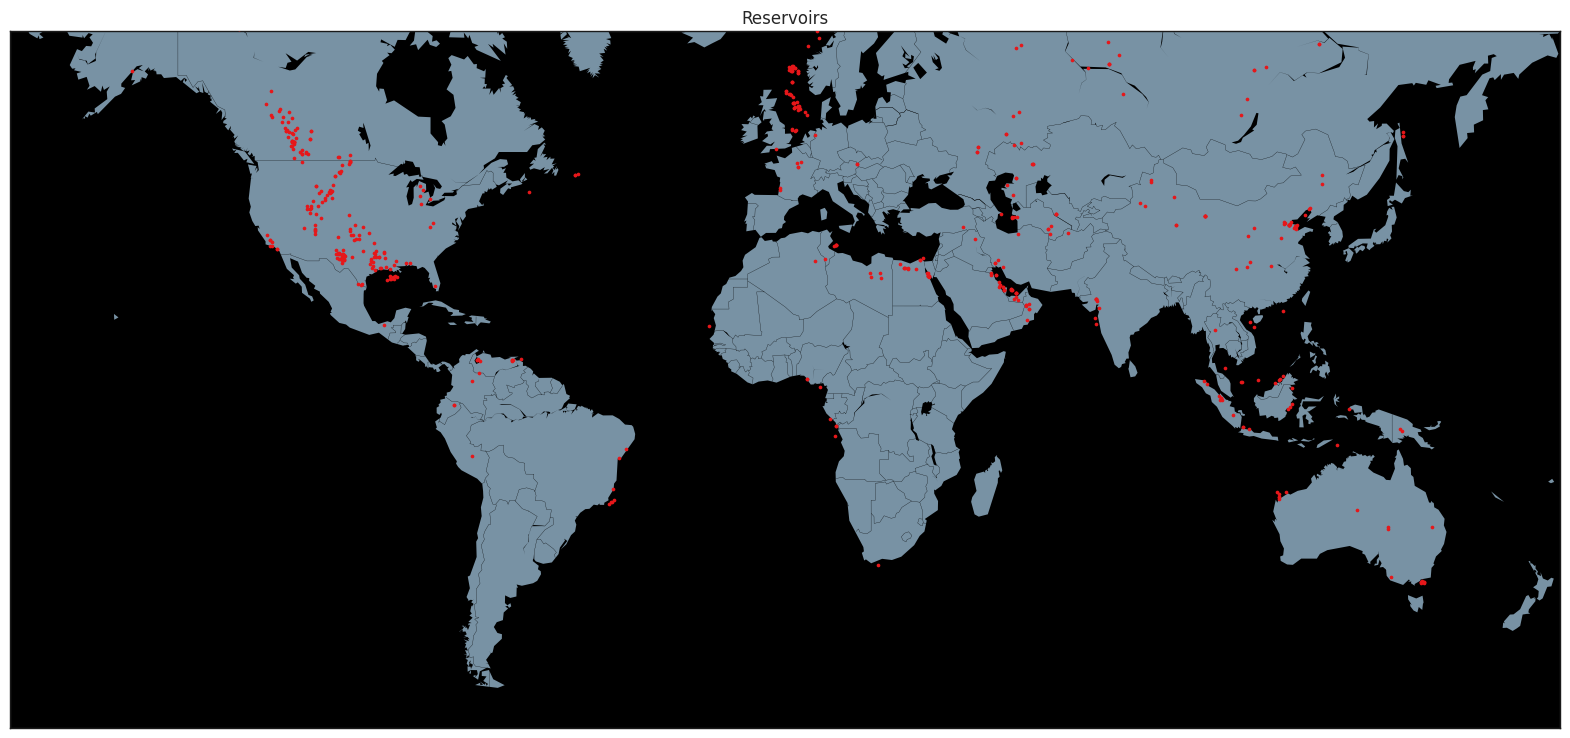

In [ ]:
plt.figure(1, figsize=(20, 12))

# Mercator of World
m1 = Basemap(
    projection='merc',
    llcrnrlat=-60,
    urcrnrlat=65,
    llcrnrlon=-180,
    urcrnrlon=180,
    lat_ts=0,
    resolution='c',
)

m1.fillcontinents(color='#7892A4',lake_color='#000000') # dark grey land, black lakes
m1.drawmapboundary(fill_color='#000000')                # black background
m1.drawcountries(linewidth=0.2, color="#000000")        # thin white line for country borders

# Plot the data
mxy = m1(data["Longitude"].tolist(), data["Latitude"].tolist())
m1.scatter(mxy[0], mxy[1], s=7, c="#E6171A", lw=0, alpha=1, zorder=5)

plt.title("Reservoirs")
plt.show()

## Категориальные признаки

In [ ]:
cat_cols = df.select_dtypes(include='object')
cat_cols.head()

,Field_name,Reservoir_unit,Country,Region,Basin_name,Tectonic_regime,Operator_company,Onshore_or_offshore,Hydrocarbon_type_(main),Reservoir_status_(current),Structural_setting,Reservoir_period,Lithology_(main)
0,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,JURASSIC,LIMESTONE
1,ABU GHARADIG,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,GUPCO,ONSHORE,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,CRETACEOUS,SANDSTONE
2,ABU MADI-EL QARA,ABU MADI (LEVEL II),EGYPT,AFRICA,NILE DELTA,STRIKE-SLIP,IEOC,ONSHORE,GAS,DECLINING PRODUCTION,WRENCH,NEOGENE,THINLY-BEDDED SANDSTONE
3,ABU MADI-EL QARA,ABU MADI (LEVEL III),EGYPT,AFRICA,NILE DELTA,STRIKE-SLIP,IEOC,ONSHORE,GAS,DECLINING PRODUCTION,WRENCH,NEOGENE,SANDSTONE
4,AL HUWAISAH,SHUAIBA,OMAN,MIDDLE EAST,FAHUD SALT,COMPRESSION,PDO,ONSHORE,OIL,REJUVENATING,SALT,CRETACEOUS,LIMESTONE


In [ ]:
cat_cols.shape

(442, 13)

In [ ]:
cat_cols.describe()

,Field_name,Reservoir_unit,Country,Region,Basin_name,Tectonic_regime,Operator_company,Onshore_or_offshore,Hydrocarbon_type_(main),Reservoir_status_(current),Structural_setting,Reservoir_period,Lithology_(main)
count,442,442,442,442,442,442,442,442,442,442,442,442,442
unique,388,353,49,7,116,9,180,3,6,13,12,15,17
top,LAOJUNMIAO,BRENT,USA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,NUMEROUS,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,CRETACEOUS,SANDSTONE
freq,3,9,120,171,40,214,39,307,332,131,122,122,248


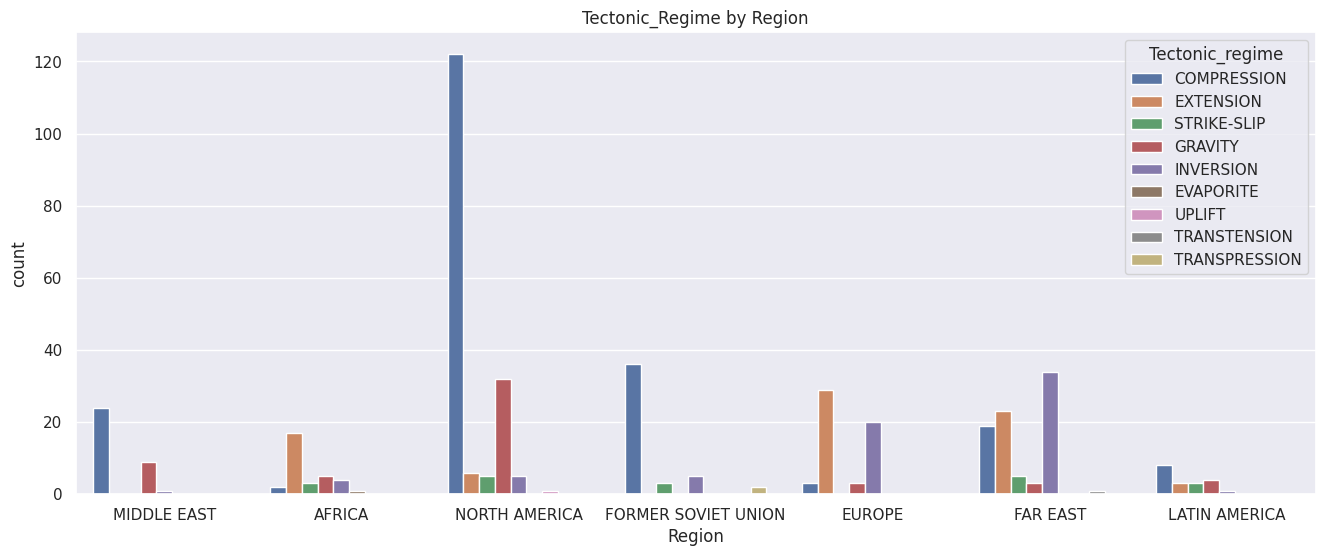

In [ ]:
f, ax=plt.subplots(figsize=(16, 6))
sns.countplot(df, x='Region', hue='Tectonic_regime', )
ax.set_title('Tectonic_Regime by Region')
plt.show()

In [ ]:
pd.crosstab(df['Region'], df['Tectonic_regime'], margins=True).style.background_gradient(cmap='summer_r')

Tectonic_regime,COMPRESSION,EVAPORITE,EXTENSION,GRAVITY,INVERSION,STRIKE-SLIP,TRANSPRESSION,TRANSTENSION,UPLIFT,All
Region,,,,,,,,,,
AFRICA,2,1,17,5,4,3,0,0,0,32
EUROPE,3,0,29,3,20,0,0,0,0,55
FAR EAST,19,0,23,3,34,5,0,1,0,85
FORMER SOVIET UNION,36,0,0,0,5,3,2,0,0,46
LATIN AMERICA,8,0,3,4,1,3,0,0,0,19
MIDDLE EAST,24,0,0,9,1,0,0,0,0,34
NORTH AMERICA,122,0,6,32,5,5,0,0,1,171
All,214,1,78,56,70,19,2,1,1,442


### Попробуем закодировать категории

In [ ]:
NEED_LABEL_ENCODING = True

In [ ]:
if NEED_LABEL_ENCODING:
    le = LabelEncoder()
    for c in cat_cols.columns:
        df[c] = le.fit_transform(cat_cols[c])
df.head()

,num,Field_name,Reservoir_unit,Country,Region,Basin_name,Tectonic_regime,Latitude,Longitude,Operator_company,...,Hydrocarbon_type_(main),Reservoir_status_(current),Structural_setting,Depth_(top_reservoir_ft_TVD),Reservoir_period,Lithology_(main),Thickness_(gross_average_ft),Thickness_(net_pay_average_ft),Porosity_(matrix_average_%),Permeability_(air_average_mD)
0,6,0,22,35,5,99,0,26.0800,49.8100,138,...,5,8,2,6050,5,9,250.0,184.0,21.0,410.0
1,10,1,28,12,0,0,2,29.7422,28.4925,61,...,3,5,6,10282,3,11,745.0,144.0,10.0,8.0
2,11,2,4,12,0,59,5,31.4382,31.3616,68,...,2,2,11,9843,7,15,115.0,66.0,22.0,200.0
3,12,2,5,12,0,59,5,31.4382,31.3616,68,...,2,2,11,10499,7,11,509.0,410.0,20.0,300.0
4,20,3,261,30,5,27,0,21.9607,56.0452,109,...,5,8,7,4955,3,9,250.0,100.0,21.0,60.0


In [ ]:
df_class = df['Tectonic_regime']

## Зависимость с целевыми переменными

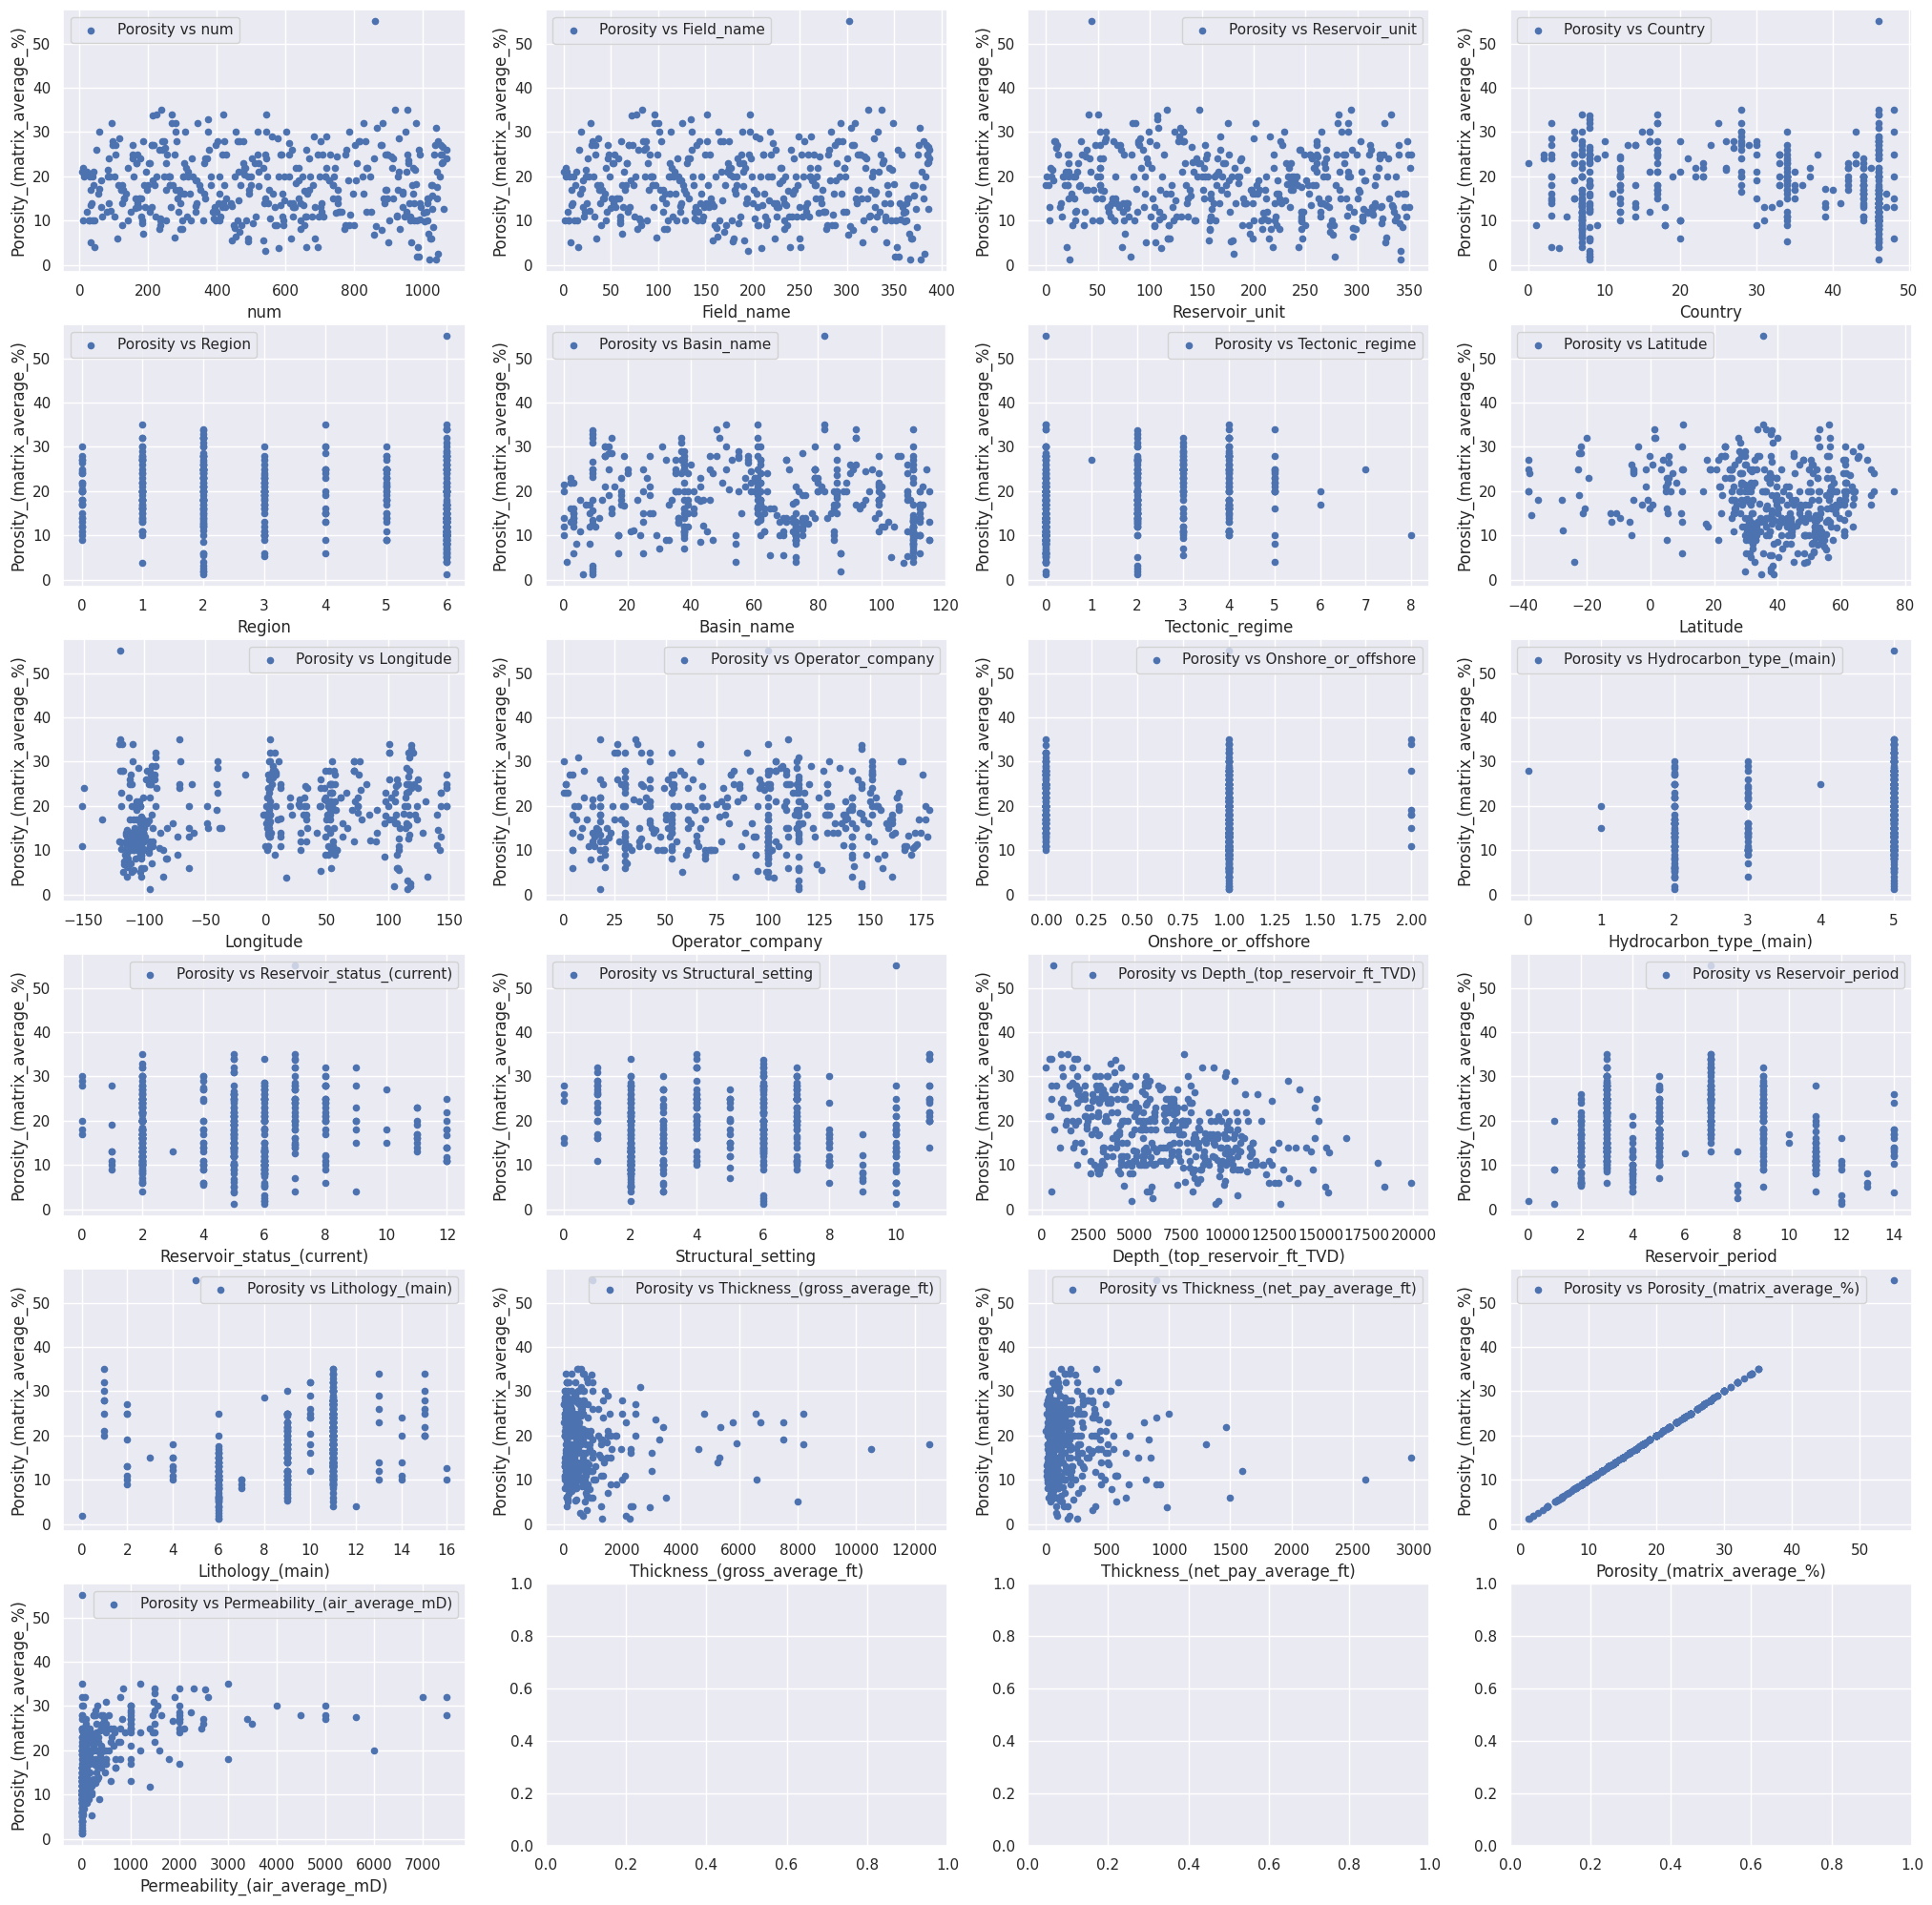

In [ ]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(25, 25))
for idx, feature in enumerate(df.columns):
    df.plot(feature, "Porosity_(matrix_average_%)", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4], label=f'Porosity vs {feature}')

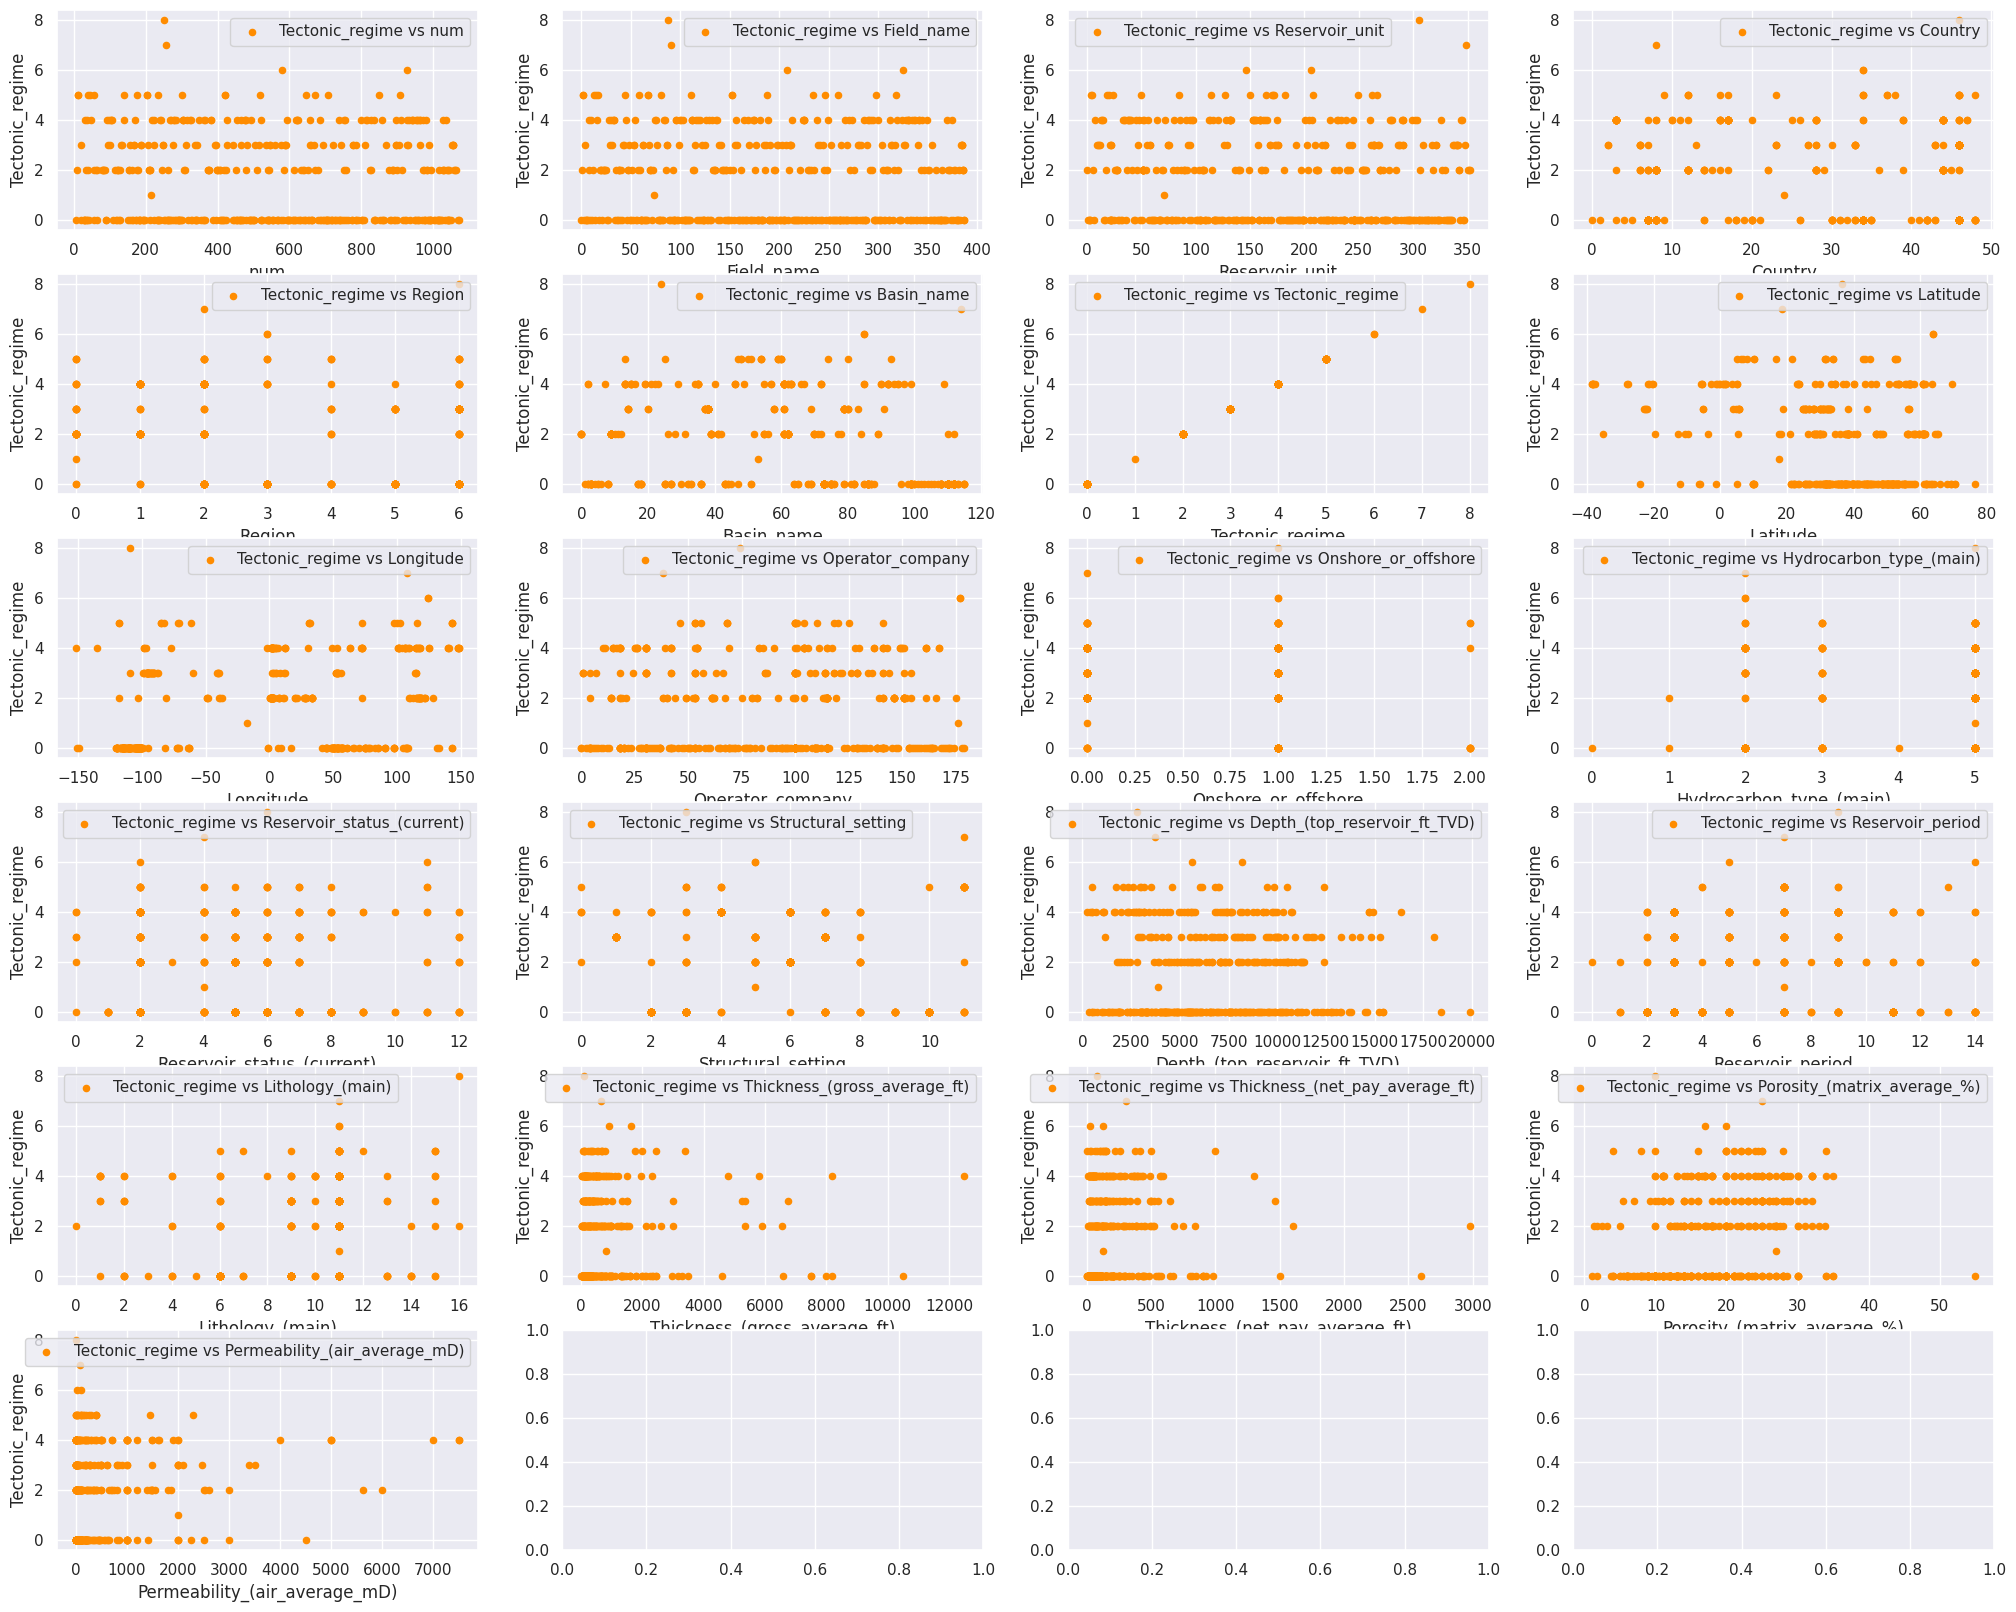

In [ ]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(25, 20))
for idx, feature in enumerate(df.columns):
    df.plot(feature, "Tectonic_regime", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4], color='darkorange', label=f'Tectonic_regime vs {feature}')

## Выбросы

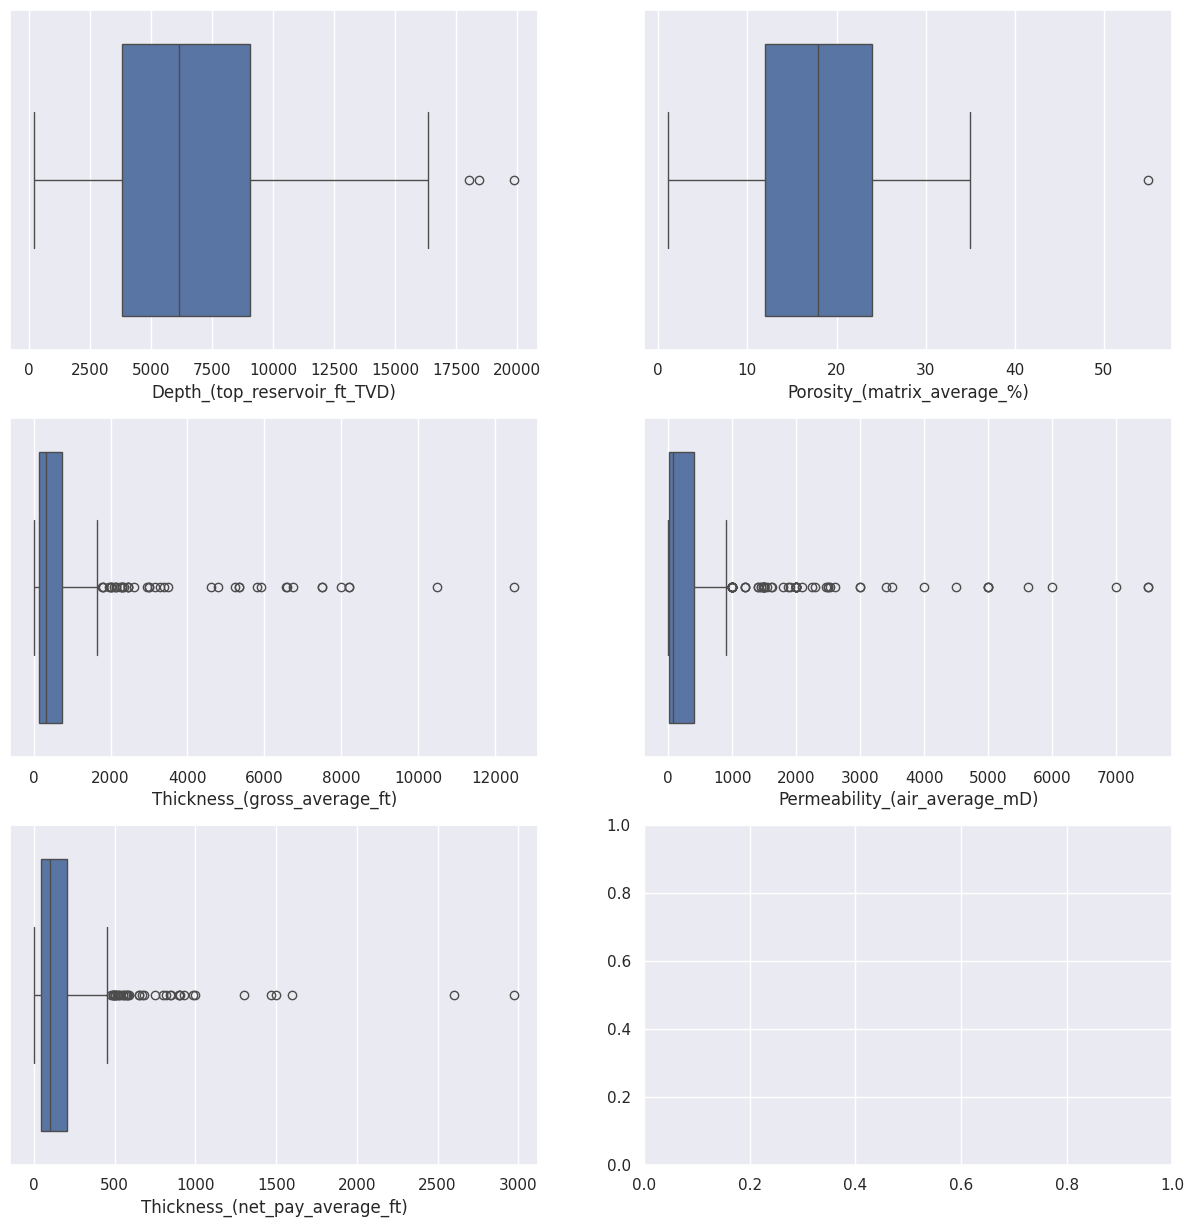

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
count = 0
for idx, feature in enumerate(num_cols.columns[3:]):
    sns.boxplot(x=df[feature], ax=axes[count % 3, count // 3])
    count += 1

In [ ]:
for col in num_cols.columns[3:]:
    print(f'Outliers for {col} column: {boxplot_stats(df[col]).pop(0)["fliers"]}\n')

Outliers for Depth_(top_reservoir_ft_TVD) column: [18050 19888 18425]

Outliers for Thickness_(gross_average_ft) column: [ 8000.  2100.  3000.  3400.  8200.  2000.  4600.  7500. 10500.  8200.
  2000.  1800.  3281.  2300.  7500. 12500.  6600.  5800.  5350.  3500.
  2133.  2953.  2460.  5335.  2300.  2460.  2300.  2000.  3000.  1800.
  6739.  1772.  1970.  3150.  5249.  5900.  2350.  2133.  6562.  2250.
  4800.  2460.  2615.]

Outliers for Thickness_(net_pay_average_ft) column: [ 575.  512.  816.  500.  840.  570.  500.  672.  650.  550.  580.  590.
  850.  490.  480.  800.  900.  525. 1300.  679. 2600. 1466. 1500.  928.
  984. 2976.  563.  650. 1000.  750. 1600.  902.  520.  500.  900.  490.
  535.  550.  490.  500.]

Outliers for Porosity_(matrix_average_%) column: [55.]

Outliers for Permeability_(air_average_mD) column: [3000. 5000. 5000. 1000. 2250. 1500. 1000. 1450. 1000. 1000. 1000. 2529.
 2000. 2500. 3000. 1500. 2000. 2000. 6000. 1500. 1900. 2098. 1550. 1200.
 1000. 1000. 1500. 1

## Распределения числовых признаков

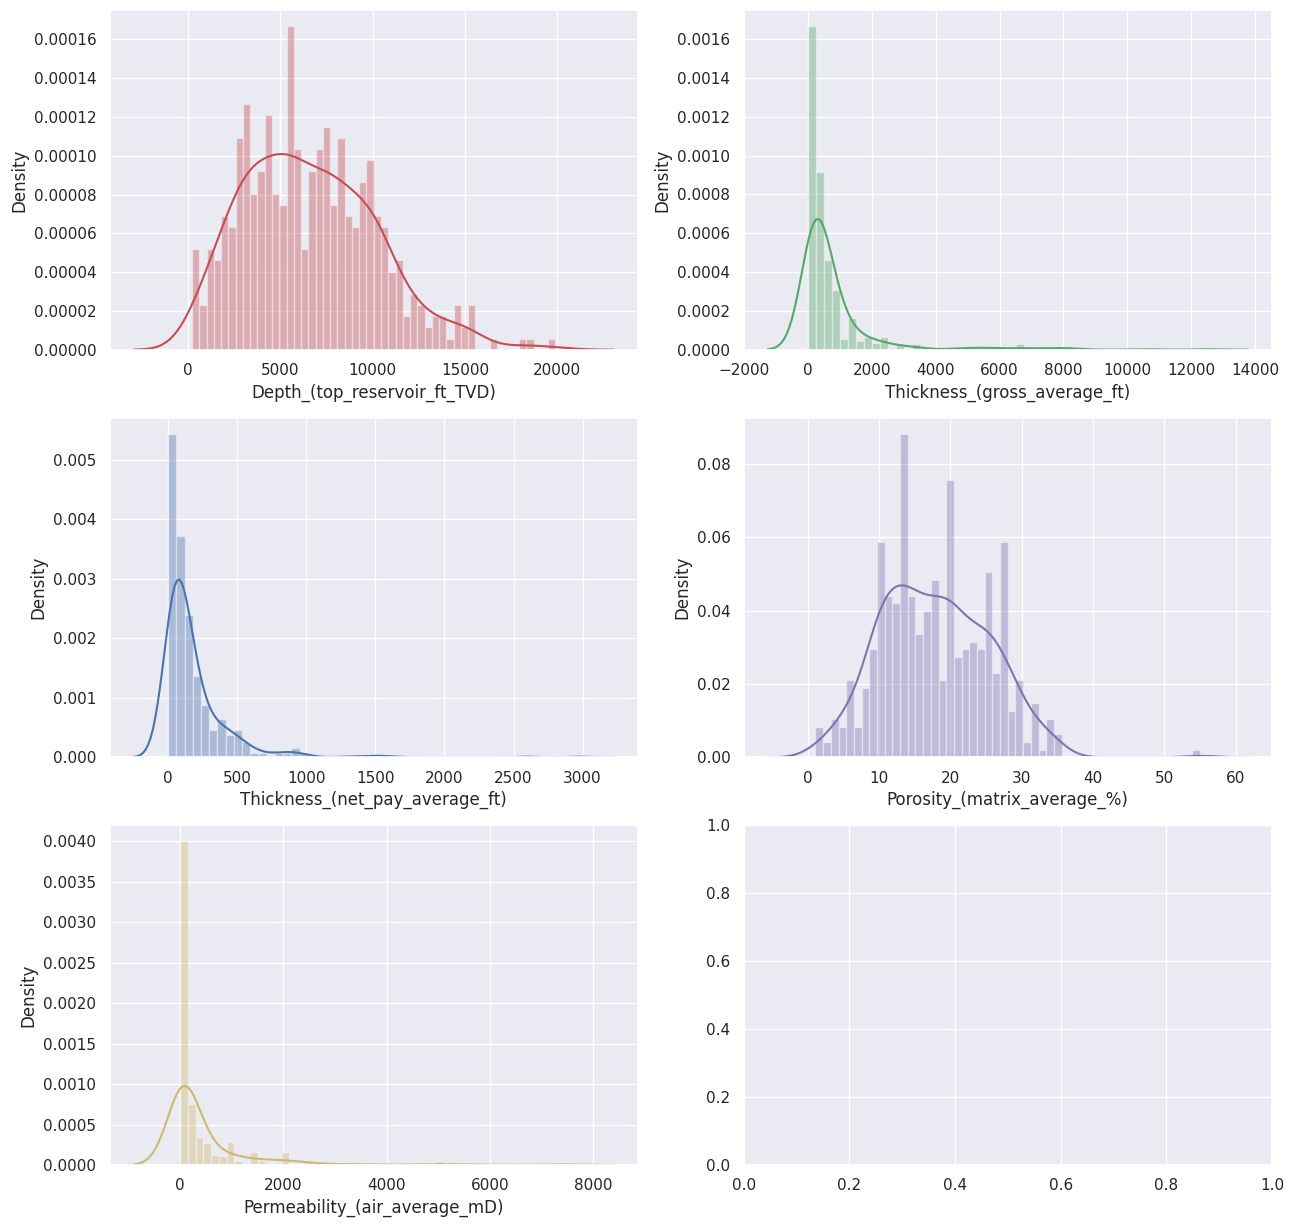

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
sns.distplot(df['Depth_(top_reservoir_ft_TVD)'], bins=50, color='r', ax=axes[0, 0])
sns.distplot(df['Thickness_(gross_average_ft)'], bins=50, color='g', ax=axes[0, 1])
sns.distplot(df['Thickness_(net_pay_average_ft)'], bins=50, color='b', ax=axes[1, 0])
sns.distplot(df['Porosity_(matrix_average_%)'].dropna(), bins=50, color='m', ax=axes[1, 1])
sns.distplot(df['Permeability_(air_average_mD)'], bins=50, color='y', ax=axes[2, 0]);

### Странный объект с аномальной пористостью

In [ ]:
data[data['Porosity_(matrix_average_%)'] > 50]

,num,Field_name,Reservoir_unit,Country,Region,Basin_name,Tectonic_regime,Latitude,Longitude,Operator_company,...,Hydrocarbon_type_(main),Reservoir_status_(current),Structural_setting,Depth_(top_reservoir_ft_TVD),Reservoir_period,Lithology_(main),Thickness_(gross_average_ft),Thickness_(net_pay_average_ft),Porosity_(matrix_average_%),Permeability_(air_average_mD)
401,861,SOUTH BELRIDGE,BELRIDGE DIATOMITE (MONTEREY-ETCHEGOIN),USA,NORTH AMERICA,SAN JOAQUIN,COMPRESSION,35.4368,-119.6788,NUMEROUS,...,OIL,PLATEAU PRODUCTION,THRUST,600,NEOGENE,DIATOMITE,1000.0,900.0,55.0,1.5


## Ковариация

**Ковариация** (covariance) измеряет направление изменения двух переменных. Другими словами она позволяет понять, как изменится одна из двух переменных при изменении второй.

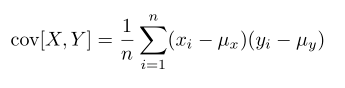

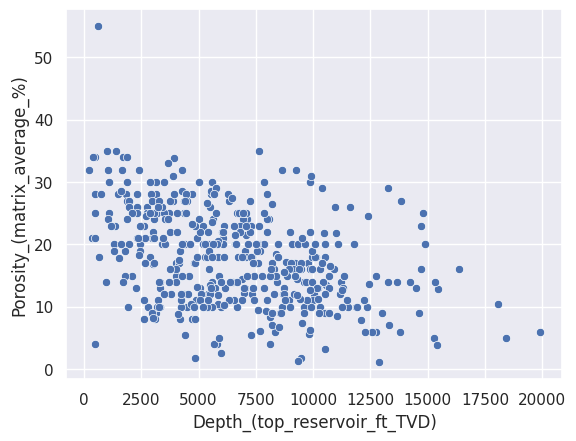

In [ ]:
sns.scatterplot(x="Depth_(top_reservoir_ft_TVD)", y="Porosity_(matrix_average_%)", data=df);

In [ ]:
df[["Depth_(top_reservoir_ft_TVD)", "Porosity_(matrix_average_%)"]].cov(ddof=1)

,Depth_(top_reservoir_ft_TVD),Porosity_(matrix_average_%)
Depth_(top_reservoir_ft_TVD),1.276253e+07,-10852.923213
Porosity_(matrix_average_%),-1.085292e+04,57.066738


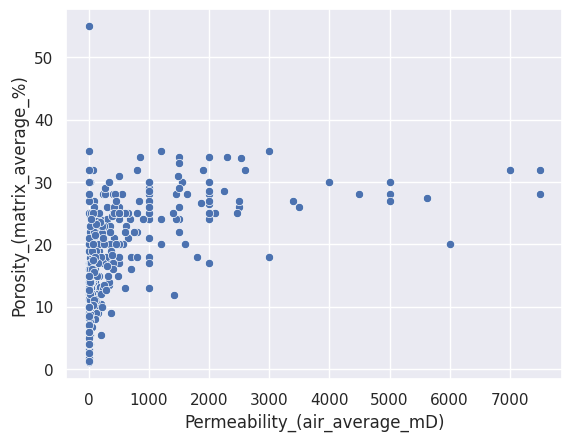

In [ ]:
sns.scatterplot(x="Permeability_(air_average_mD)", y="Porosity_(matrix_average_%)", data=df);

In [ ]:
df[["Permeability_(air_average_mD)", "Porosity_(matrix_average_%)"]].cov(ddof=1)

,Permeability_(air_average_mD),Porosity_(matrix_average_%)
Permeability_(air_average_mD),1.034454e+06,3640.723210
Porosity_(matrix_average_%),3.640723e+03,57.066738


Ковариация измеряет только направление, но не силу взаимосвязи

## Корреляция

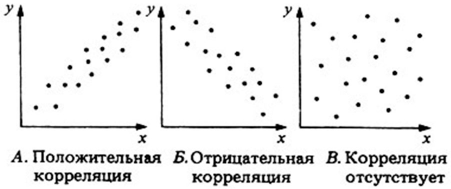

### Корреляция Пирсона

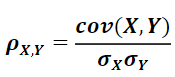

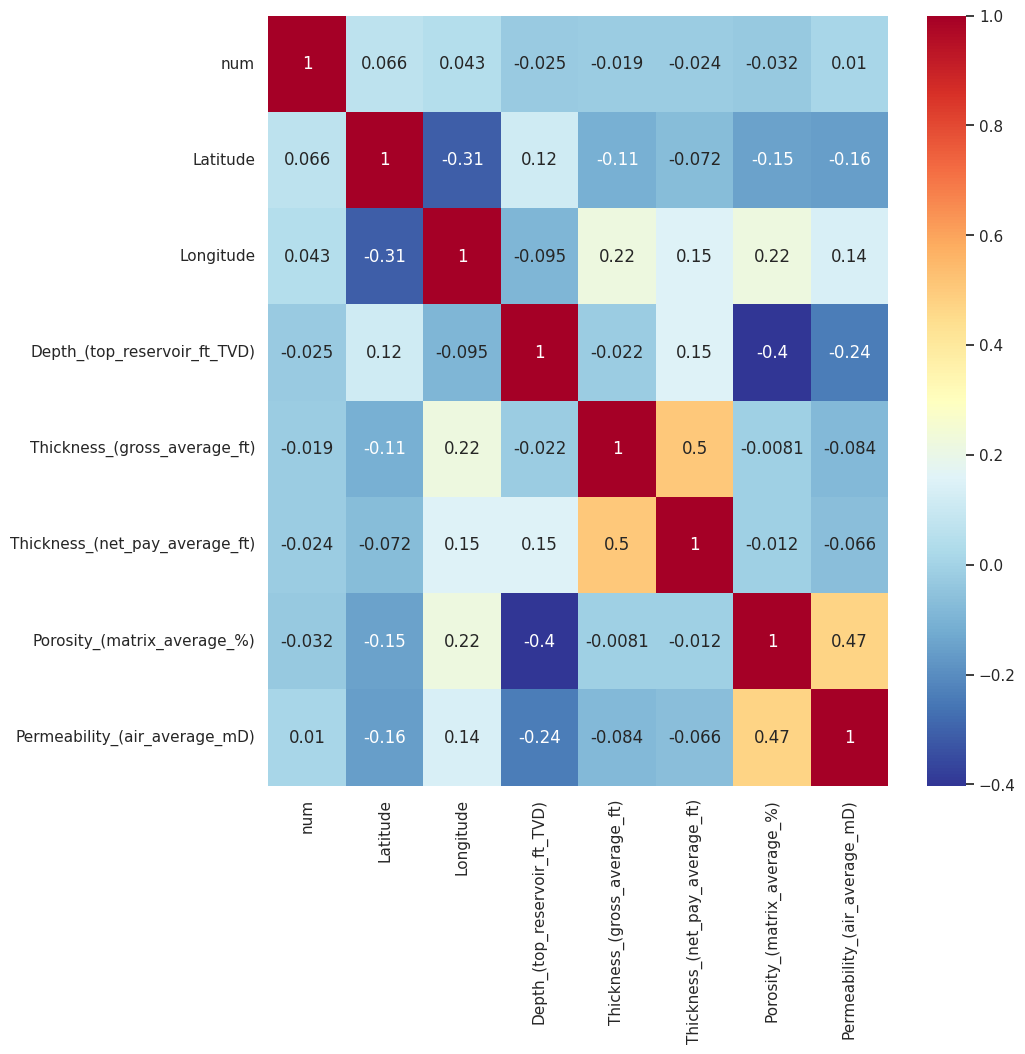

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(num_cols.corr(), cmap="RdYlBu_r", annot=True);

 * Ни ковариация, ни корреляция не устанавливают причинно-следственной связи
 * Коэффициент корреляции Пирсона измеряет взаимосвязь количественных переменных и предполагает, что обе переменные имеют нормальное распределение
 * Отсутствие линейной корреляции не означает отсутствие взаимосвязи. Возможно взаимосвязь есть, но она нелинейна
 * На коэффициент корреляции существенное влияние оказывают выбросы


### Коэффициент ранговой корреляции Спирмена

Коэффициенты Спирмена называются ранговыми, так как при их расчете анализируются не сами значения параметров, а их взаимное расположение – ранги. В этом случае параметры, между которыми рассчитывается взаимосвязи, не должны быть распределения по нормальному закону

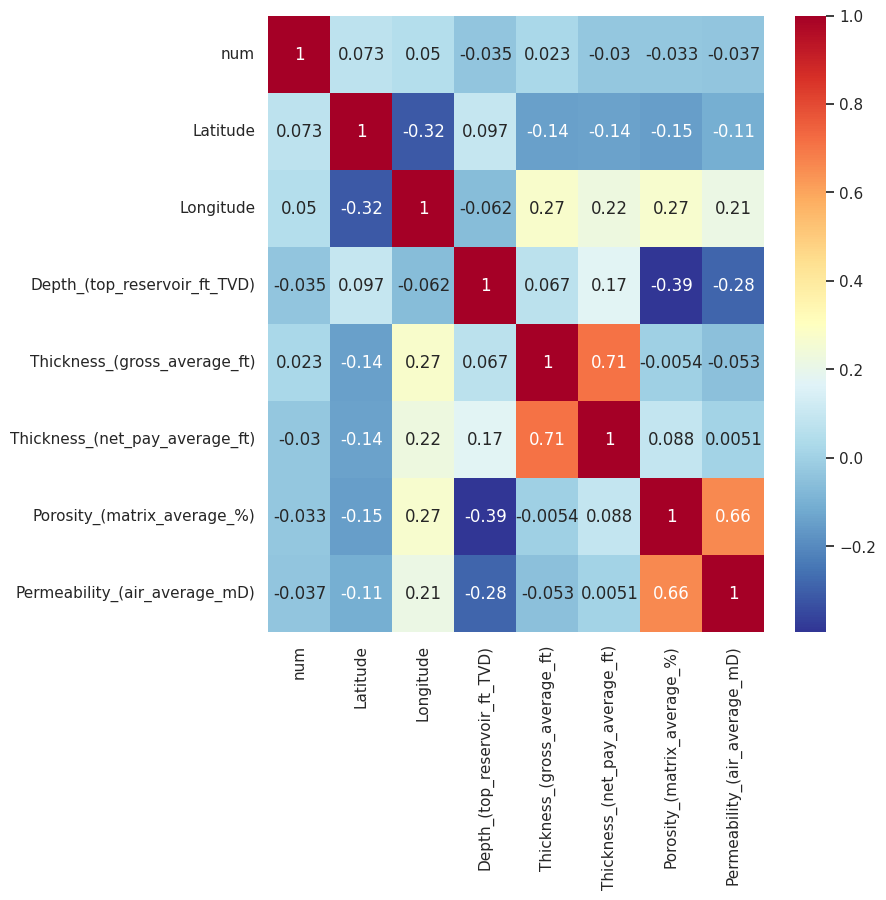

In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(num_cols.corr(method='spearman'), cmap="RdYlBu_r", annot=True);

### Phik

[repo](https://github.com/KaveIO/PhiK)

interval columns not set, guessing: ['num', 'Latitude', 'Longitude', 'Depth_(top_reservoir_ft_TVD)', 'Thickness_(gross_average_ft)', 'Thickness_(net_pay_average_ft)', 'Porosity_(matrix_average_%)', 'Permeability_(air_average_mD)']


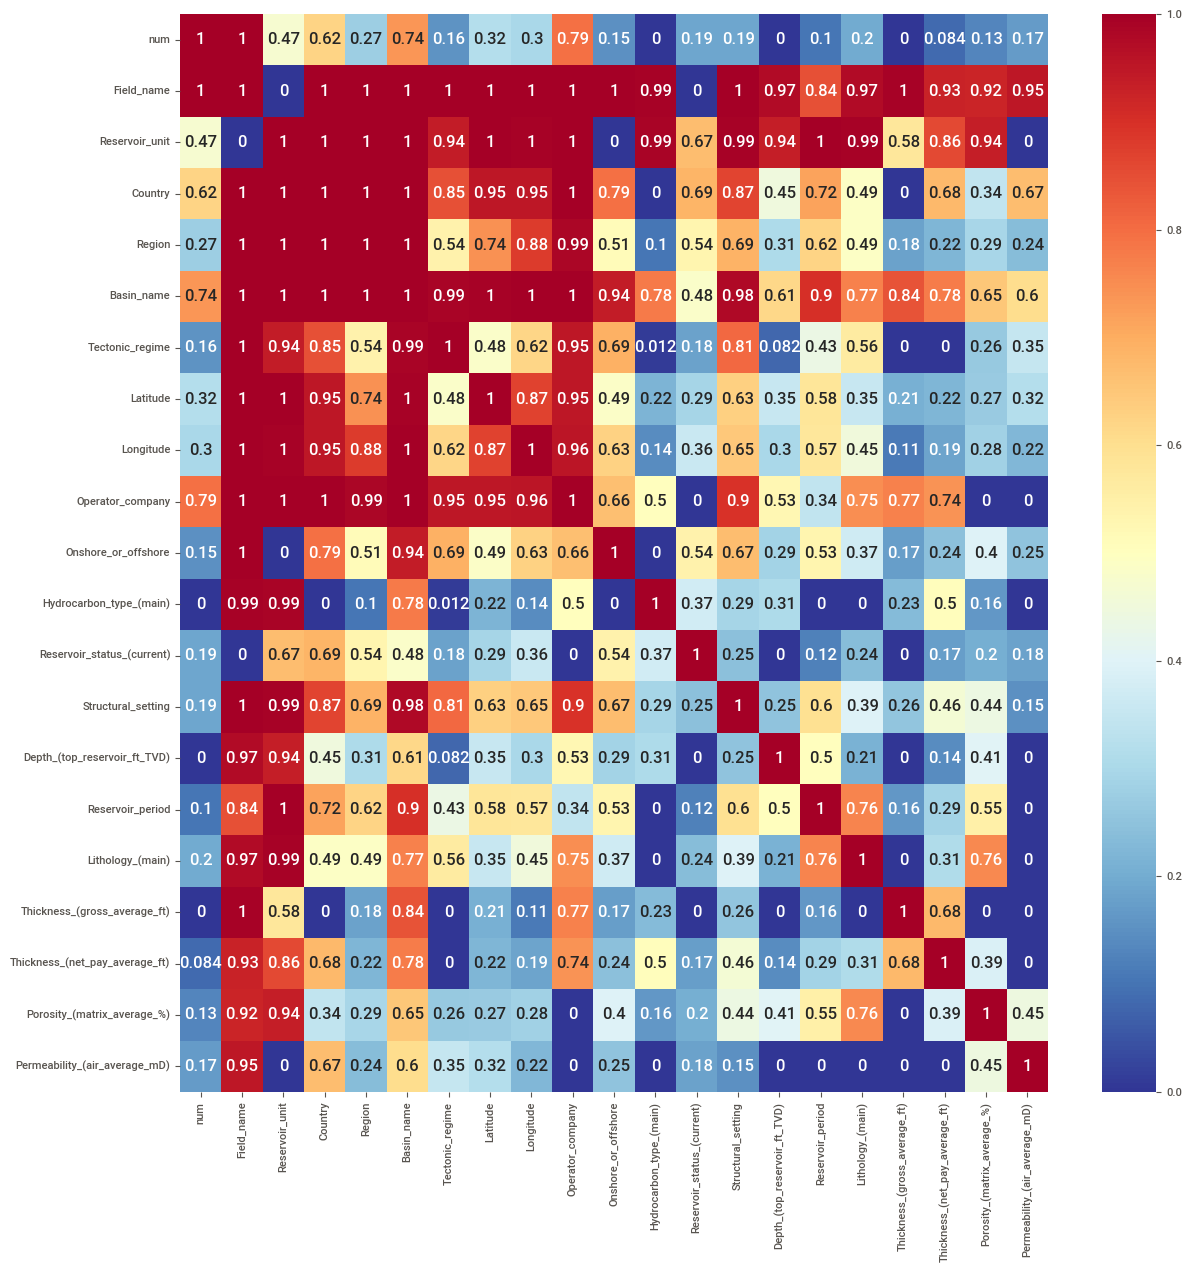

In [ ]:
plt.figure(figsize=(14, 14))
sns.heatmap(data.phik_matrix(), cmap="RdYlBu_r", annot=True);

## PCA(n_components=3)

In [ ]:
num_cols.head()

,num,Latitude,Longitude,Depth_(top_reservoir_ft_TVD),Thickness_(gross_average_ft),Thickness_(net_pay_average_ft),Porosity_(matrix_average_%),Permeability_(air_average_mD)
0,6,26.0800,49.8100,6050,250.0,184.0,21.0,410.0
1,10,29.7422,28.4925,10282,745.0,144.0,10.0,8.0
2,11,31.4382,31.3616,9843,115.0,66.0,22.0,200.0
3,12,31.4382,31.3616,10499,509.0,410.0,20.0,300.0
4,20,21.9607,56.0452,4955,250.0,100.0,21.0,60.0


In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(num_cols)
df_scaled[:5]

array([[-1.69475241, -0.41205449,  0.66246334, -0.15795719, -0.37088264,
        -0.01796023,  0.40686009, -0.05897692],
       [-1.68195626, -0.24434978,  0.4196457 ,  1.02800026, -0.02743471,
        -0.15988376, -1.05092331, -0.45467343],
       [-1.67875722, -0.16668412,  0.45232627,  0.90497679, -0.46455026,
        -0.43663466,  0.53938586, -0.26568405],
       [-1.67555818, -0.16668412,  0.45232627,  1.0888114 , -0.19117958,
         0.78390774,  0.27433433, -0.16725208],
       [-1.64996587, -0.60069138,  0.73348558, -0.46481528, -0.37088264,
        -0.31599965,  0.40686009, -0.40348881]])

In [ ]:
df_scaled.shape

(442, 8)

In [ ]:
model = PCA(n_components=3)
model.fit(df_scaled)
df_pca_3 = model.transform(df_scaled)

In [ ]:
def draw_3d(data):
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')

    for f in data:
        ax.scatter(f[0], f[1], f[2], c='b')
    plt.show()

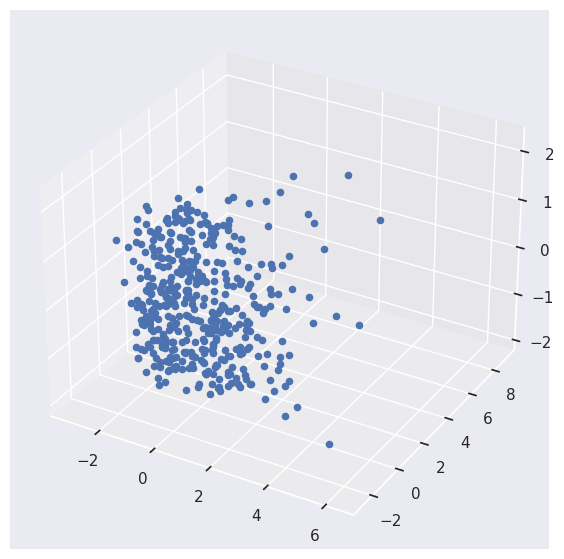

In [ ]:
draw_3d(df_pca_3)

## Визуализация классов и PCA

In [ ]:
model = PCA(n_components=2)
model.fit(df_scaled)
pca_coords = model.transform(df_scaled)
pca_coords[:5]

array([[ 0.64380066,  0.02693248],
       [-0.9733672 ,  0.60194191],
       [-0.02737344, -0.150259  ],
       [-0.1271356 ,  0.83047702],
       [ 0.69211455, -0.09424083]])

In [ ]:
df_to_draw = pd.DataFrame({
    'class': df_class,
    'pca1': pca_coords[:, 0],
    'pca2': pca_coords[:, 1],
})
colors = ['b', 'r', 'k', 'g', 'c', 'm', 'y', 'gold', 'darkorange', 'lime']

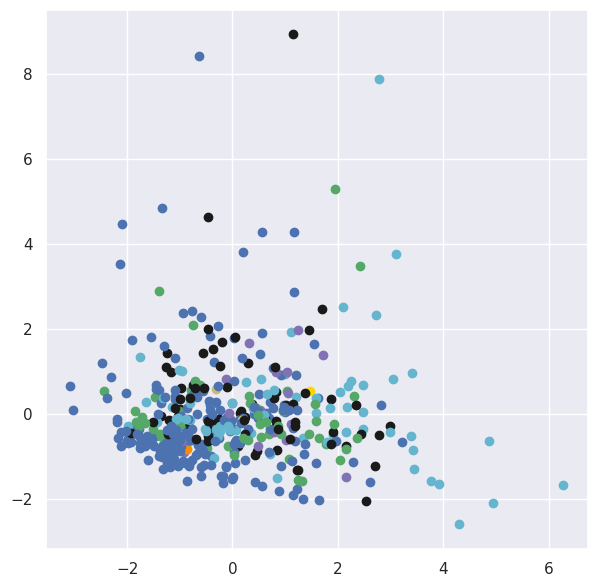

In [ ]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)

for f in df_to_draw.iterrows():
    ax.scatter(f[1]['pca1'], f[1]['pca2'], c=colors[int(f[1]['class'])])

plt.show()

3D

In [ ]:
model = PCA(n_components=3)
model.fit(df_scaled)
pca_coords = model.transform(df_scaled)
pca_coords[:5]

array([[ 0.64380066,  0.02693248, -1.66949134],
       [-0.9733672 ,  0.60194191, -1.74786868],
       [-0.02737344, -0.150259  , -1.75611042],
       [-0.1271356 ,  0.83047702, -1.69210776],
       [ 0.69211455, -0.09424083, -1.6512661 ]])

In [ ]:
# %matplotlib notebook
# from mpl_toolkits.mplot3d import axes3d

In [ ]:
df_to_draw = pd.DataFrame({
    'class': df_class,
    'pca1': pca_coords[:, 0],
    'pca2': pca_coords[:, 1],
    'pca3': pca_coords[:, 2],
})
colors = ['b', 'r', 'k', 'g', 'c', 'm', 'y', 'gold', 'darkorange', 'lime']

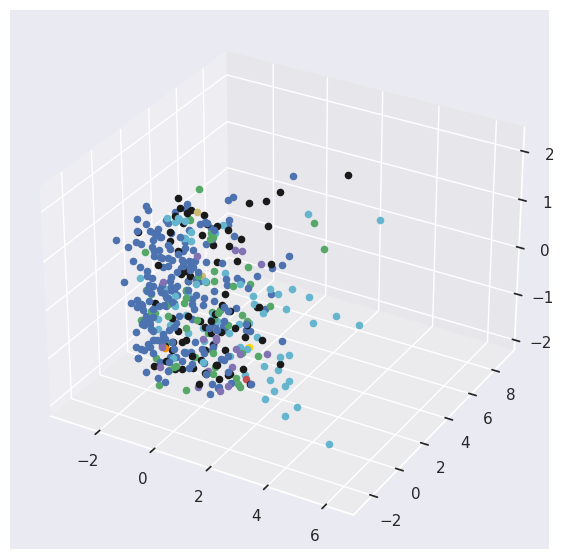

In [ ]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

for f in df_to_draw.iterrows():
    ax.scatter(f[1]['pca1'], f[1]['pca2'], f[1]['pca3'], c=colors[int(f[1]['class'])])
plt.show()

## Sweetviz

In [ ]:
np.VisibleDeprecationWarning

numpy.exceptions.VisibleDeprecationWarning

In [ ]:
comparison = sv.compare(train, test)

                                             |          | [  0%]   00:00 -> (? left)


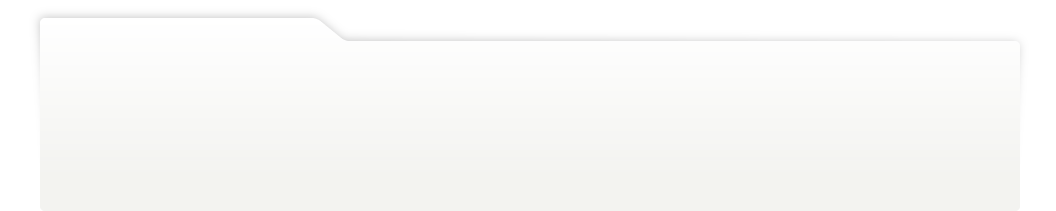
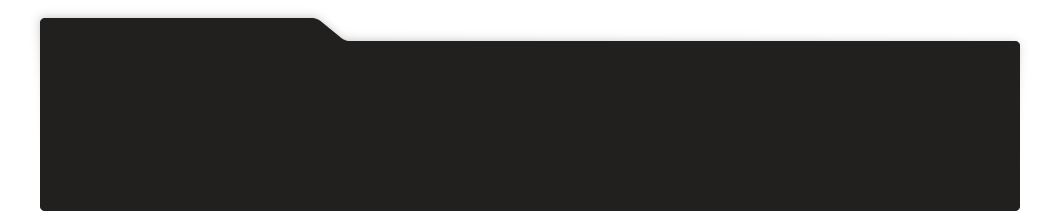
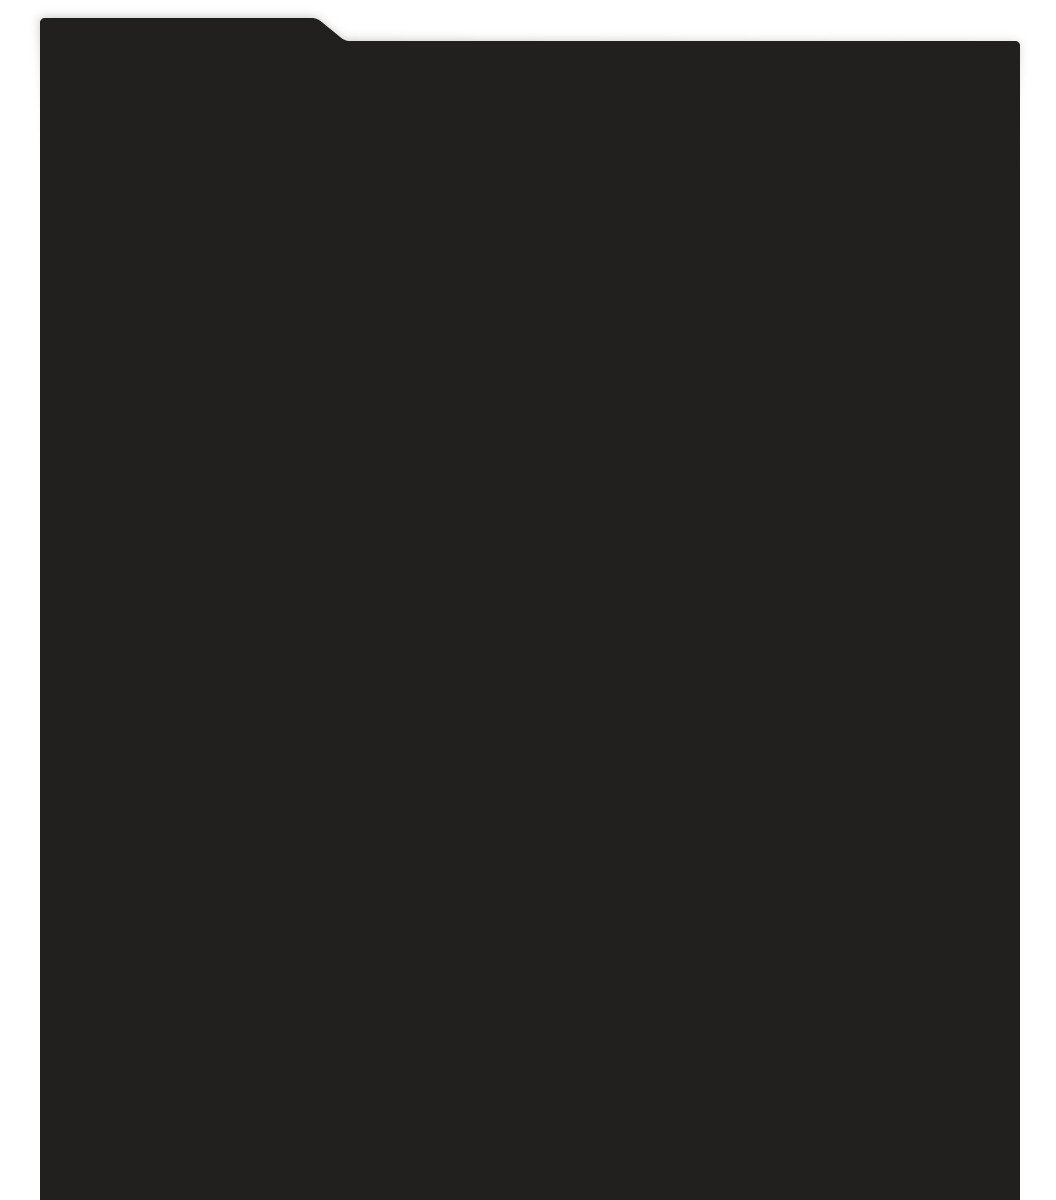
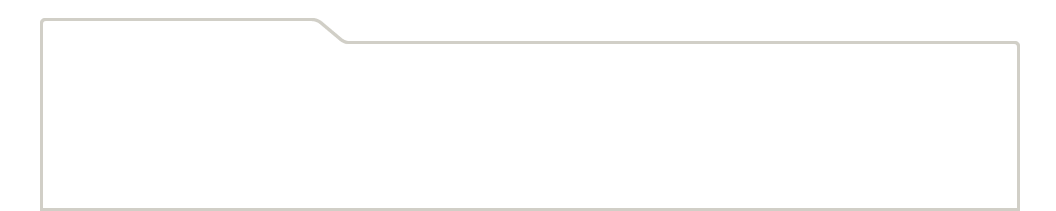
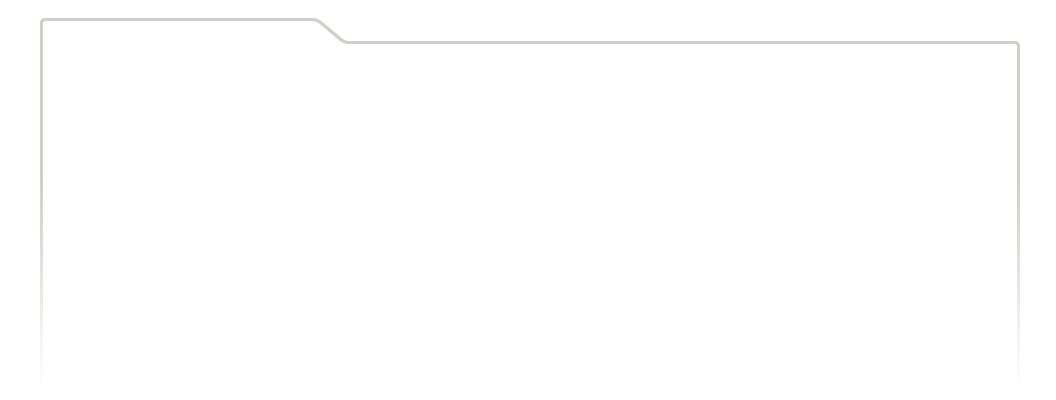
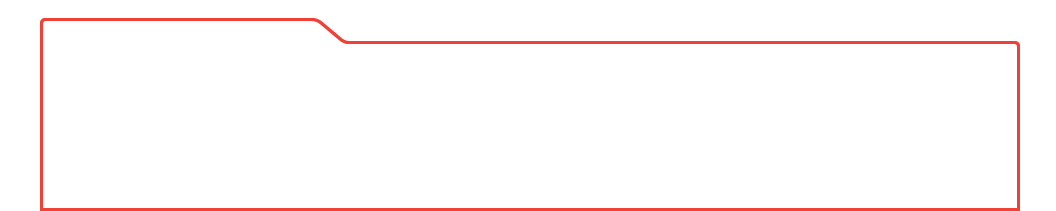
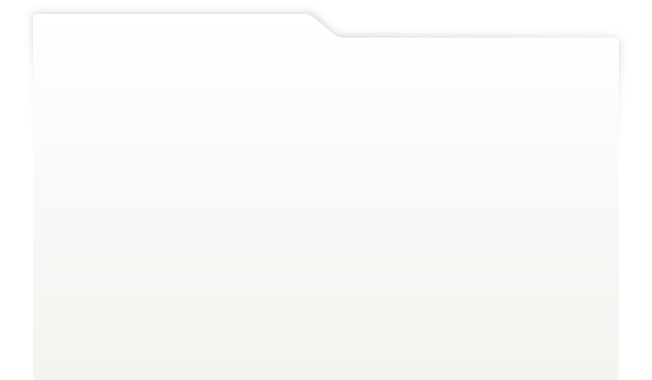
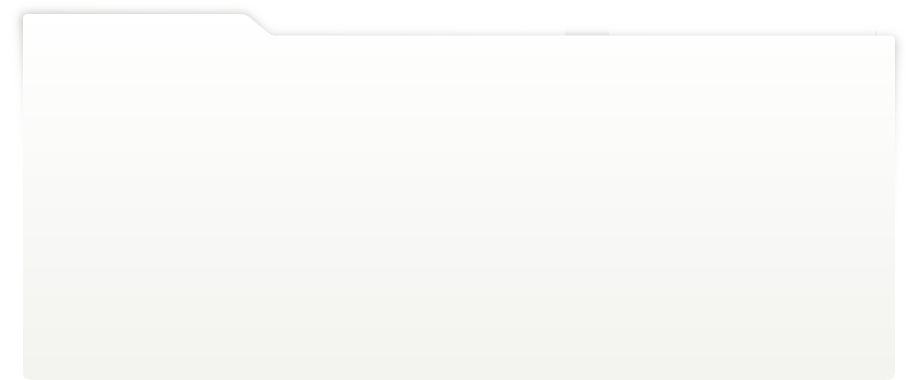
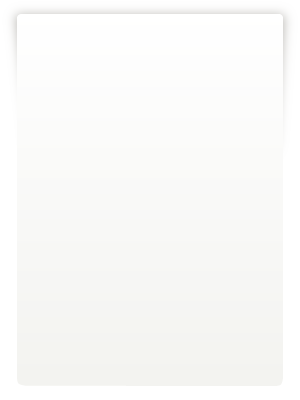
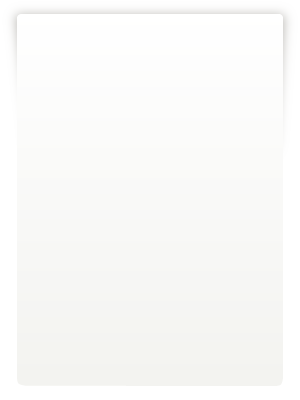
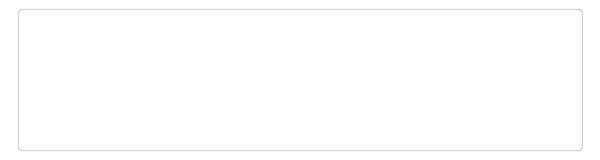
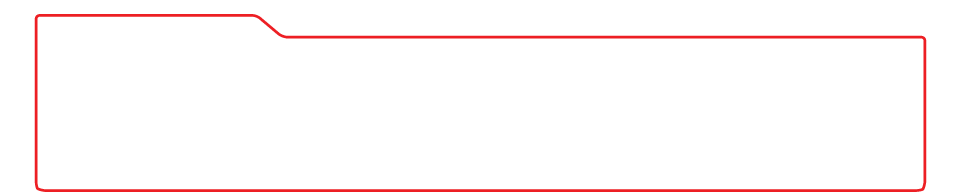
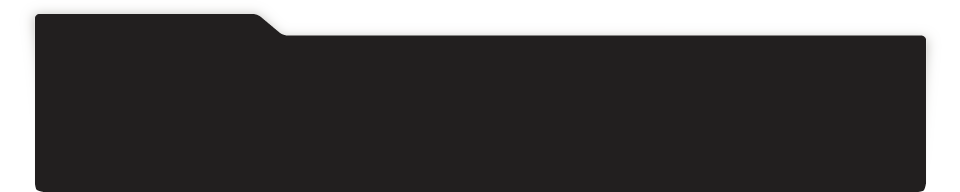
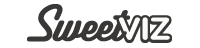
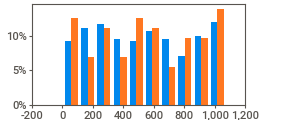
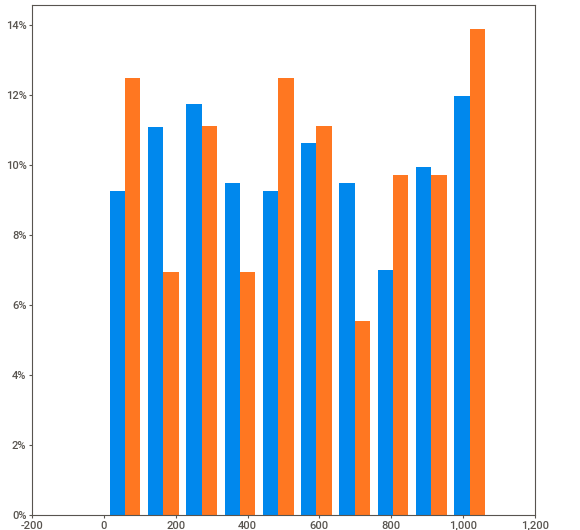
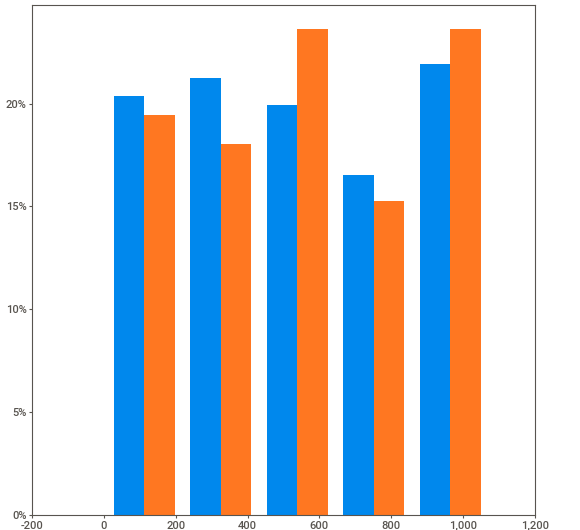
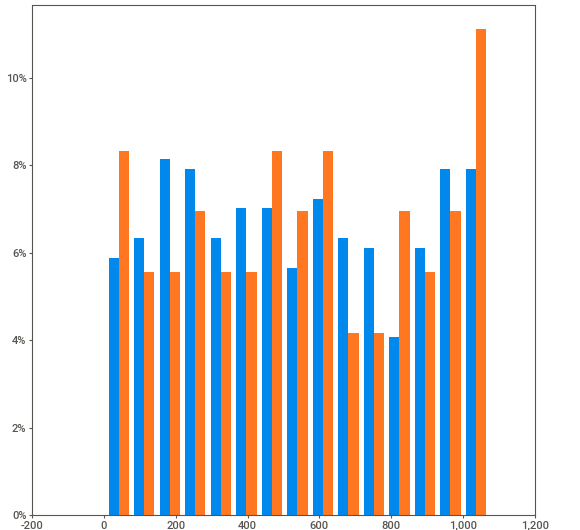
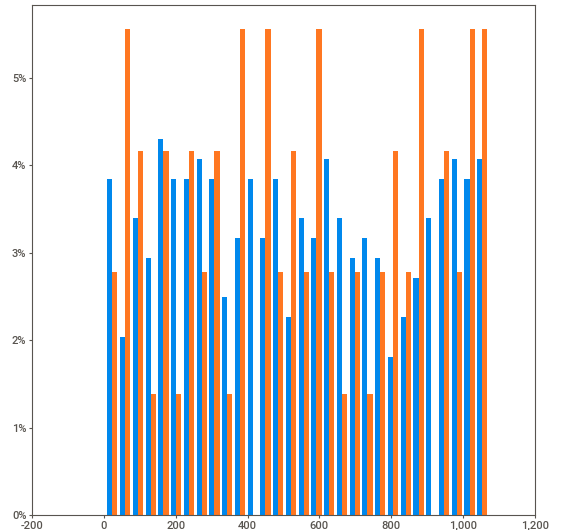
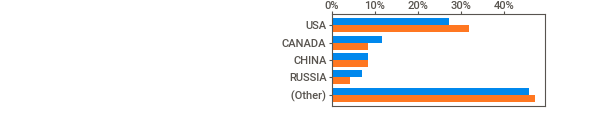
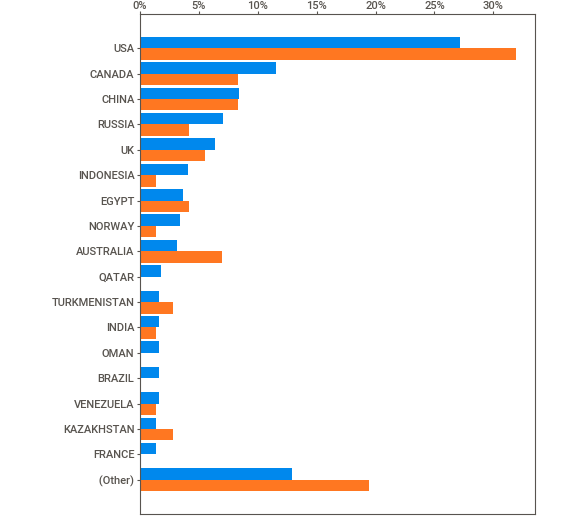
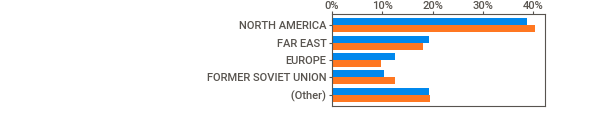
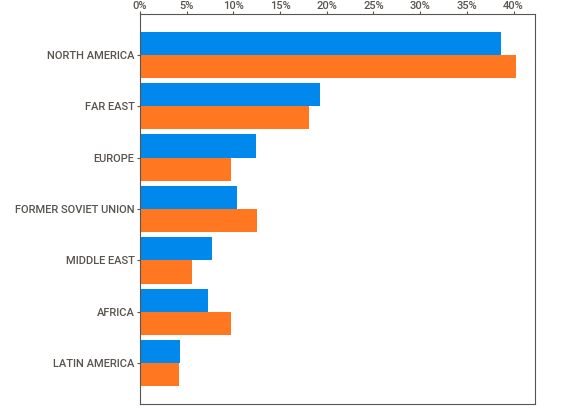
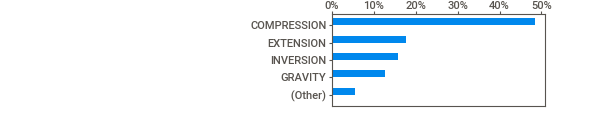
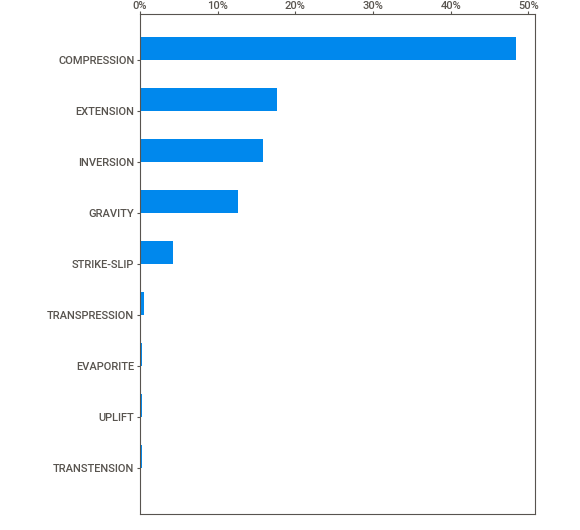
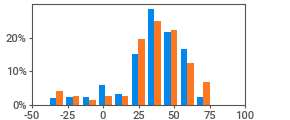
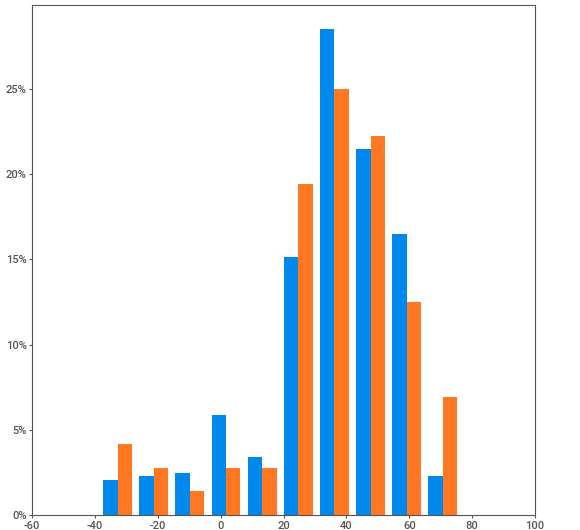
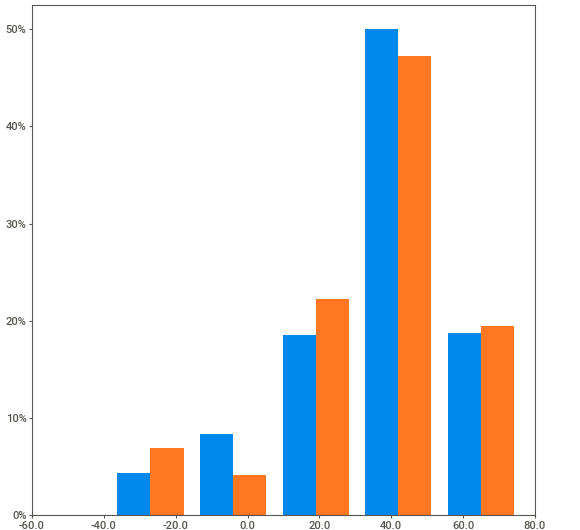
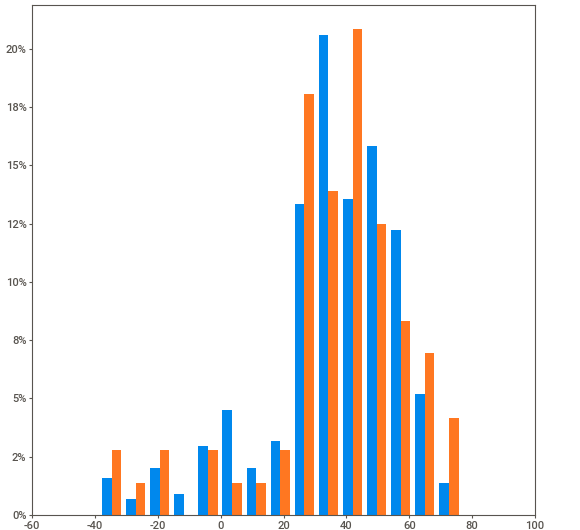
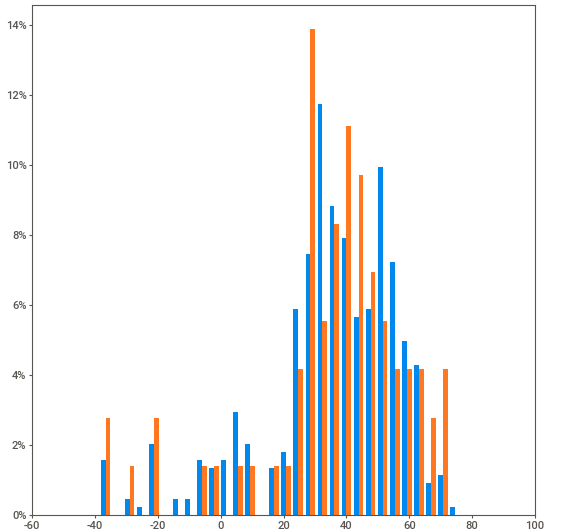
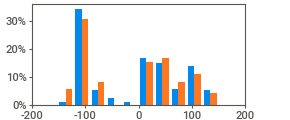
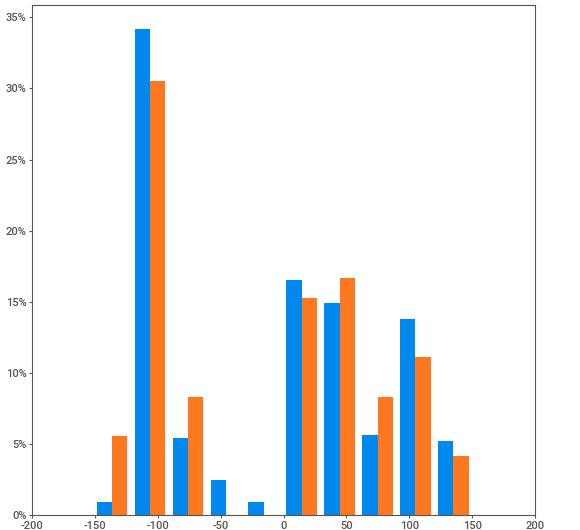
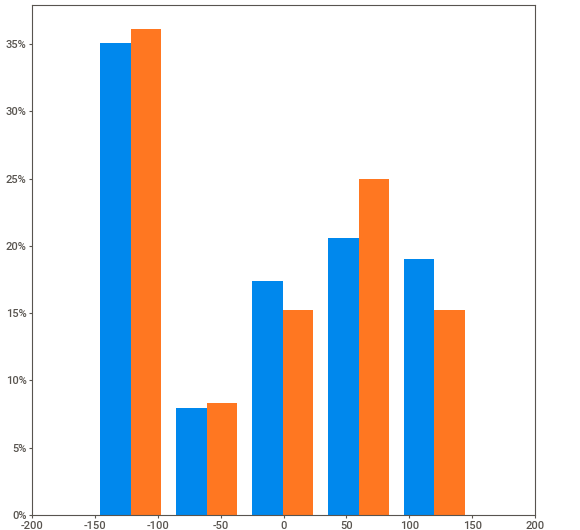
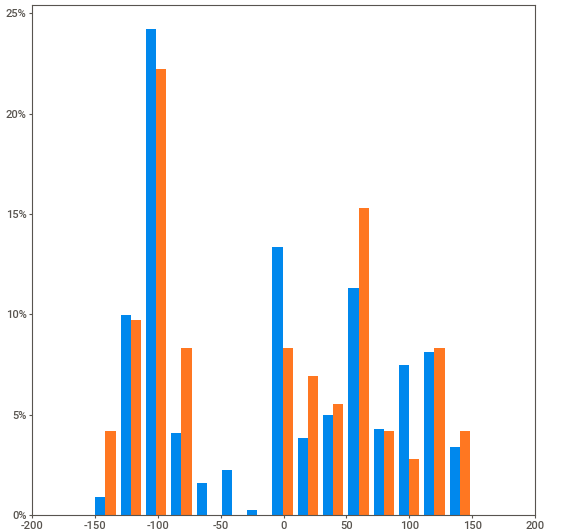
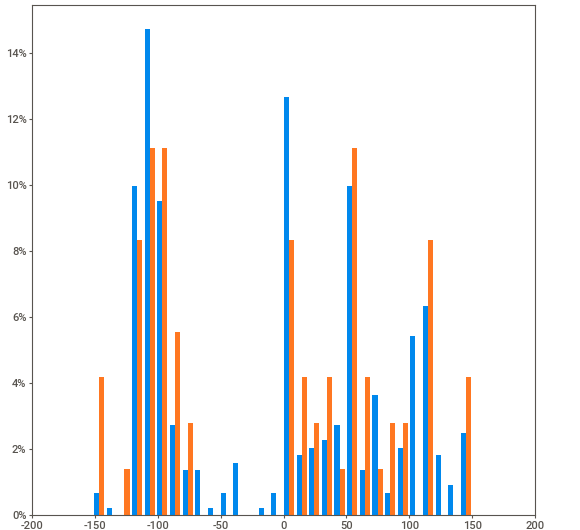
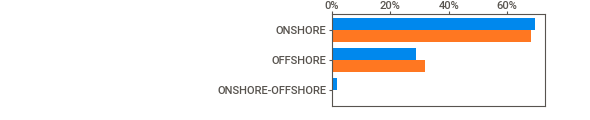
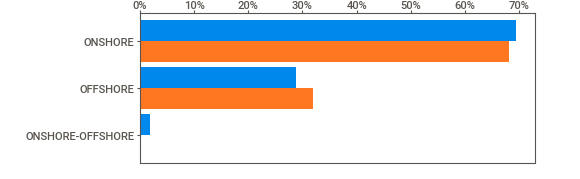
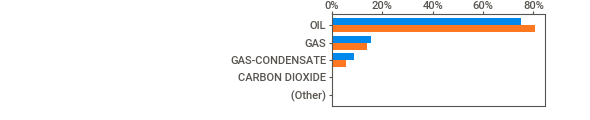
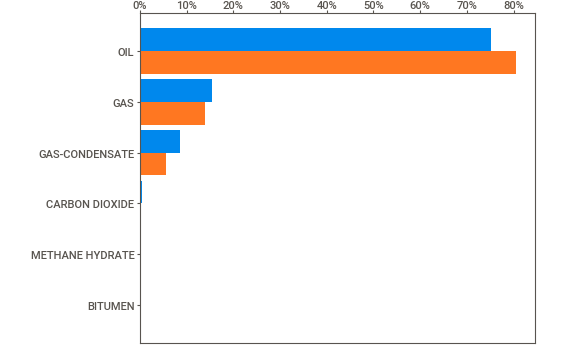
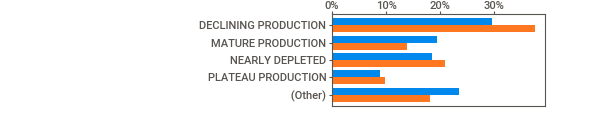
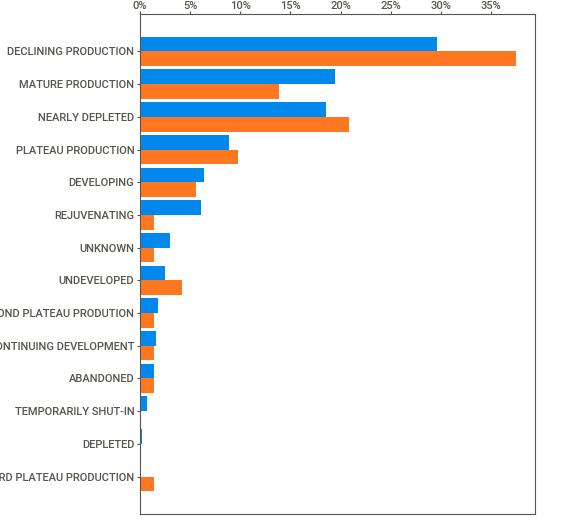
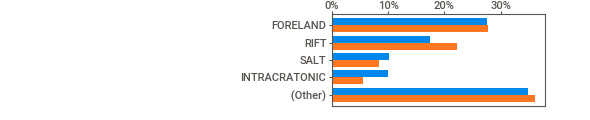
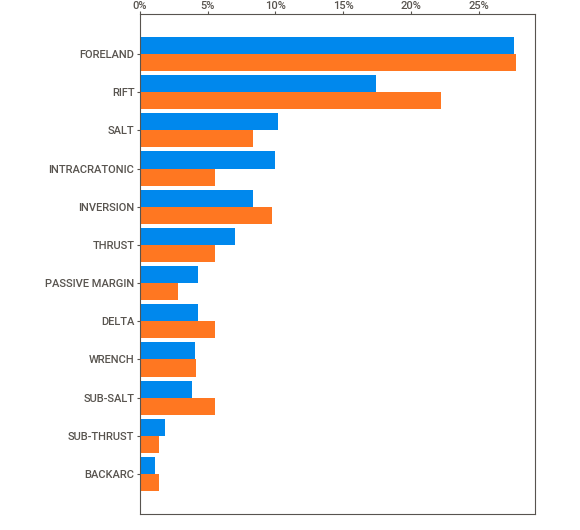
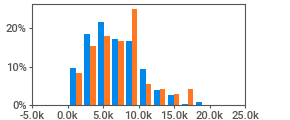
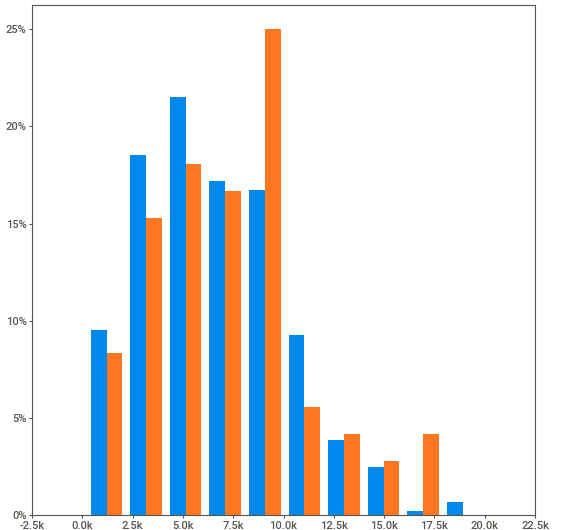
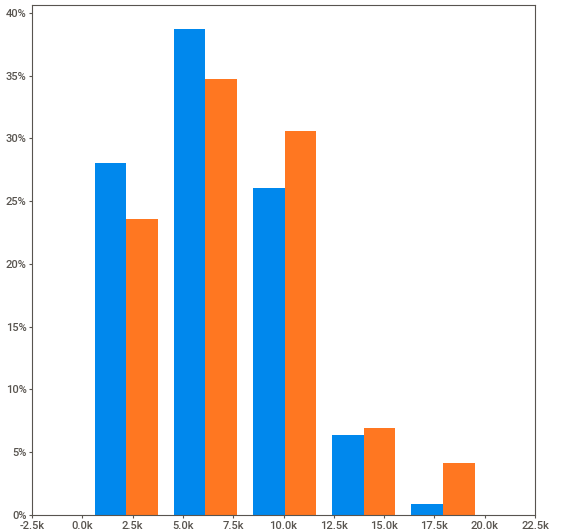
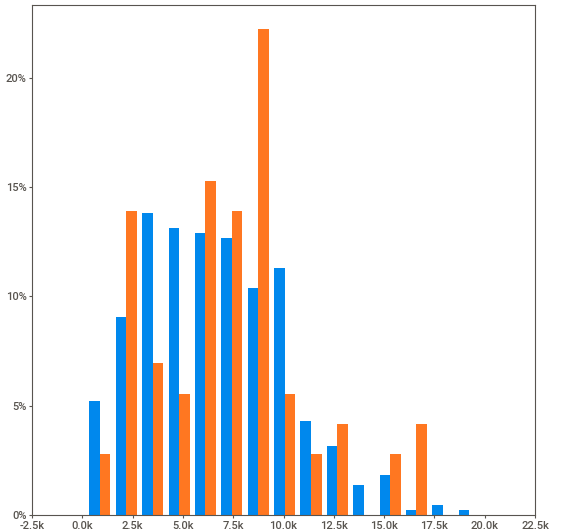
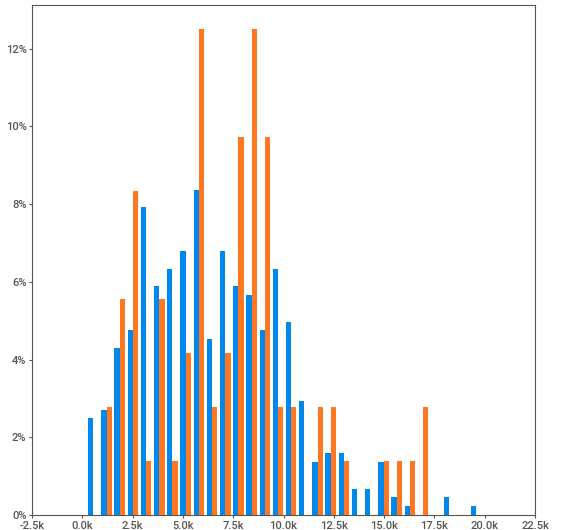
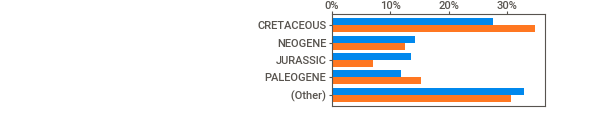
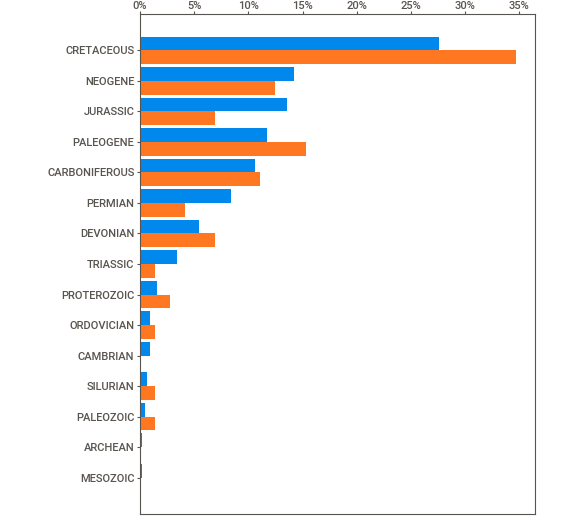
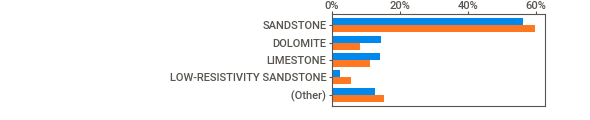
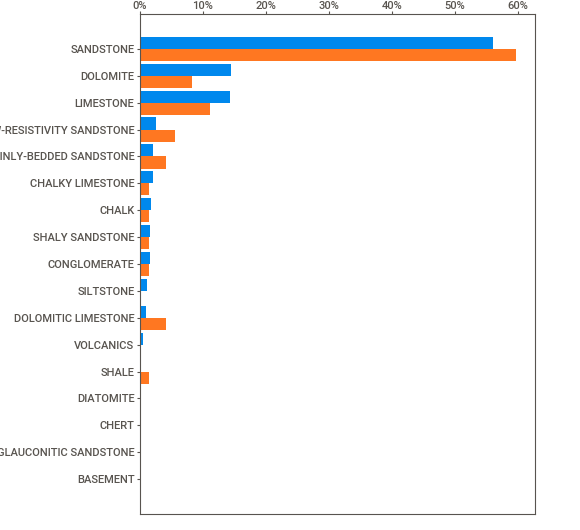
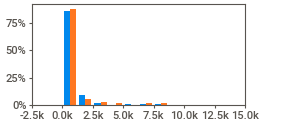
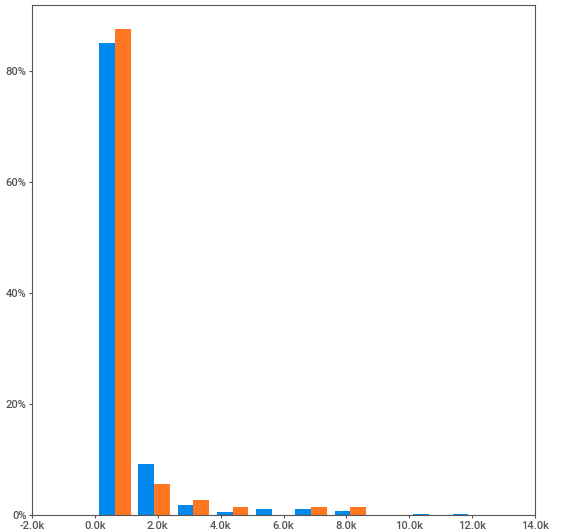
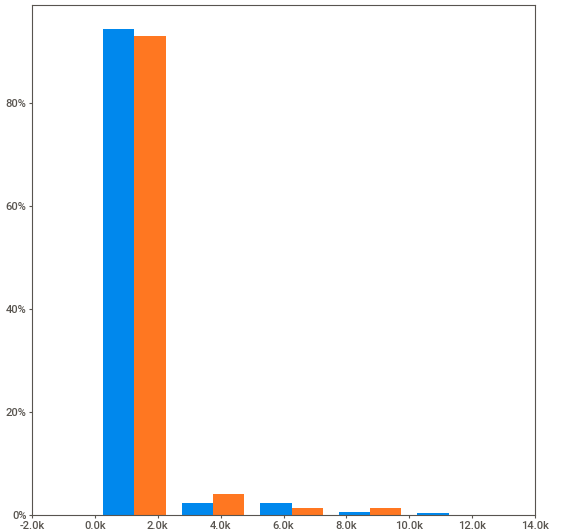
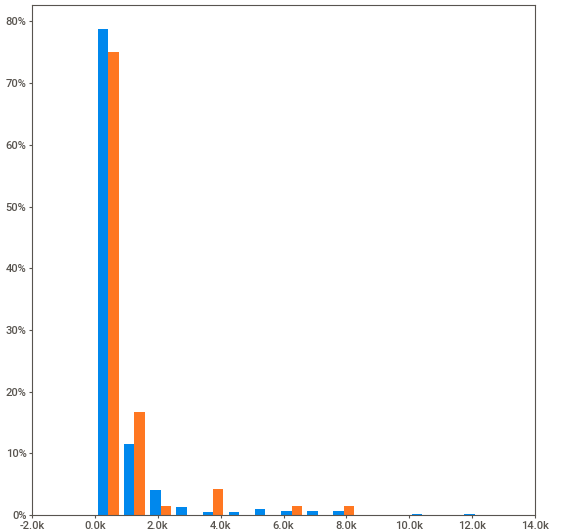
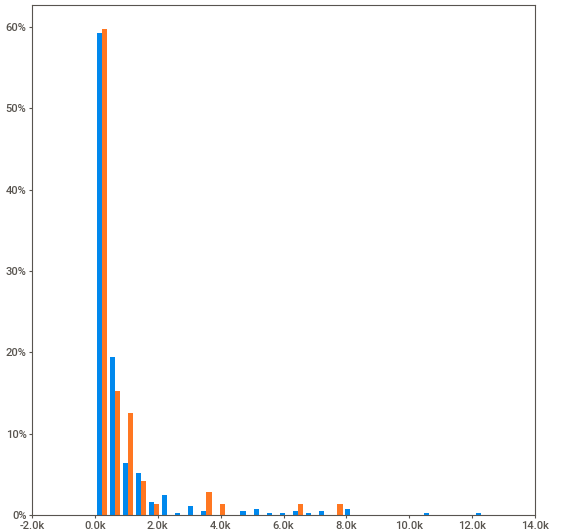
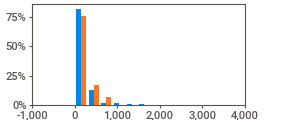
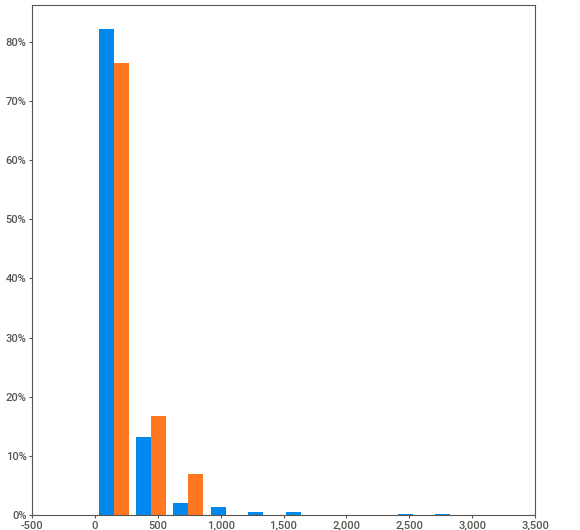
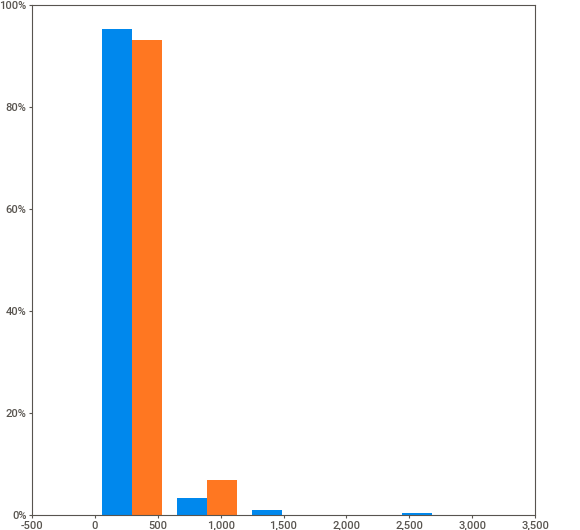
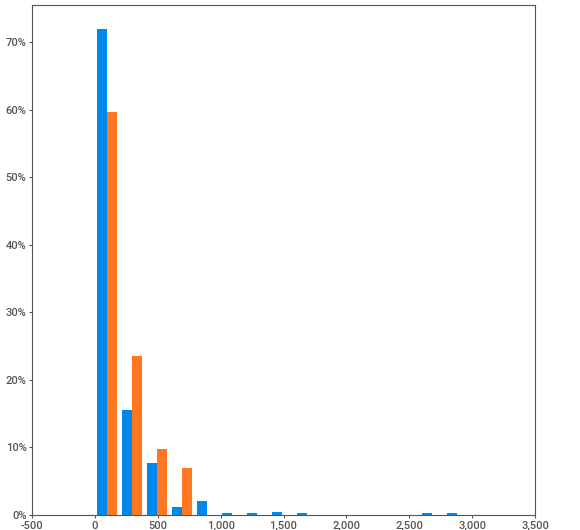
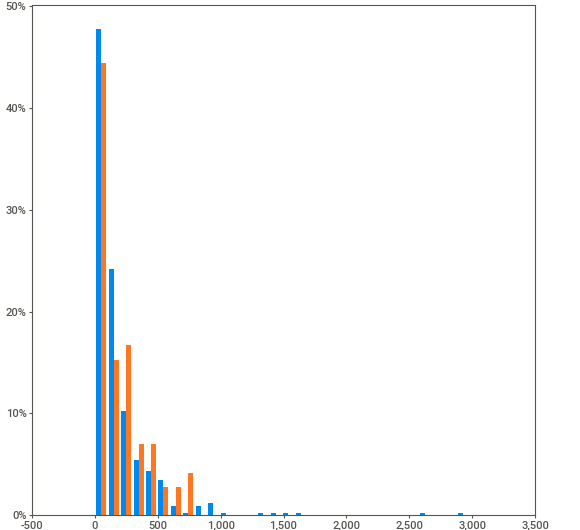
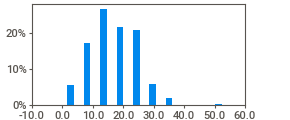
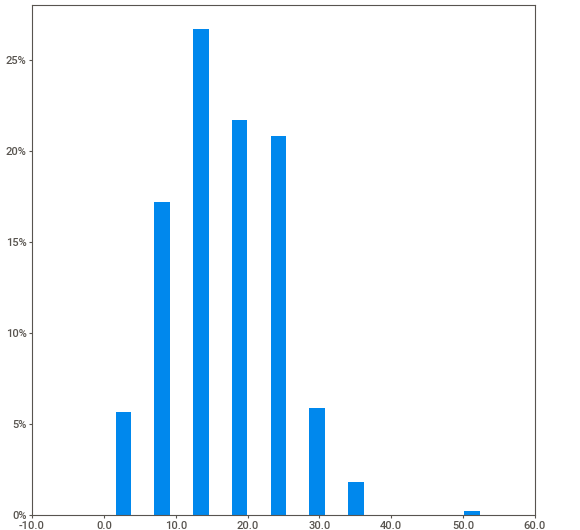
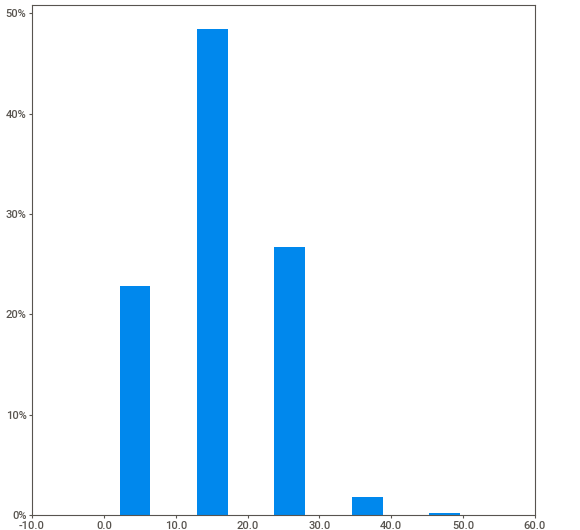
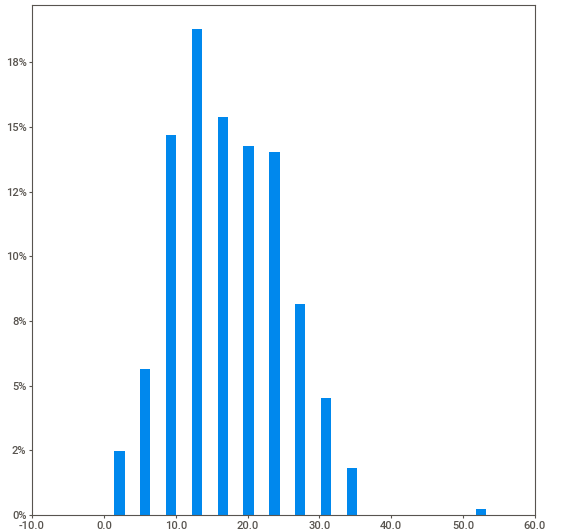
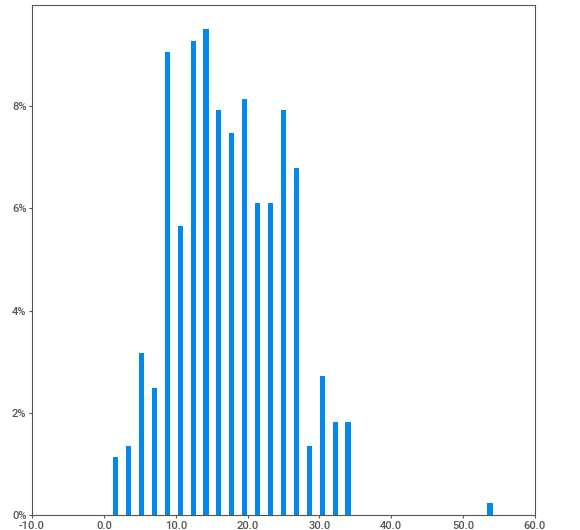
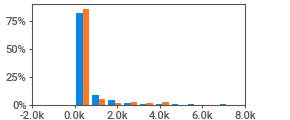
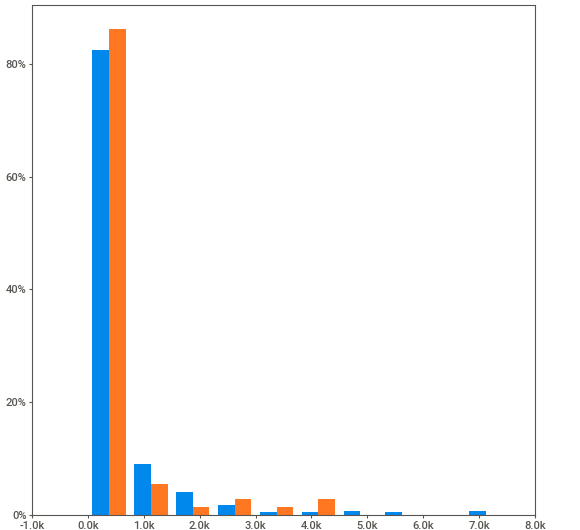
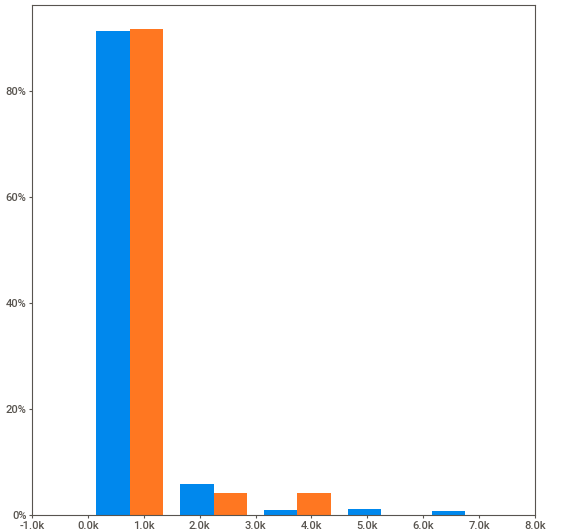
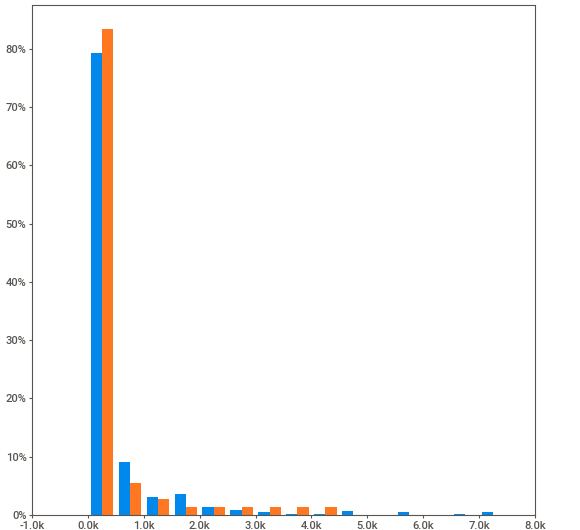
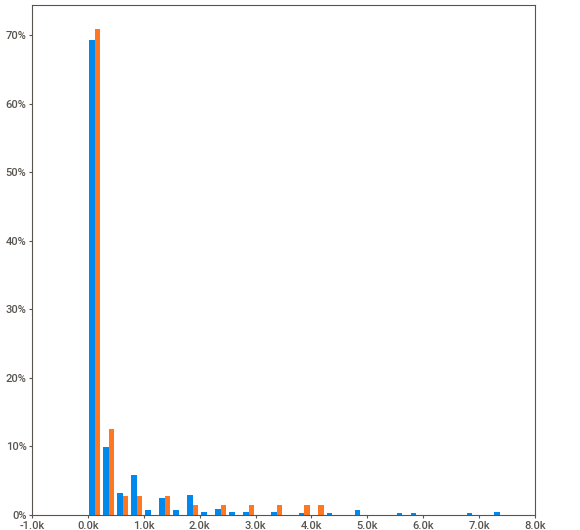
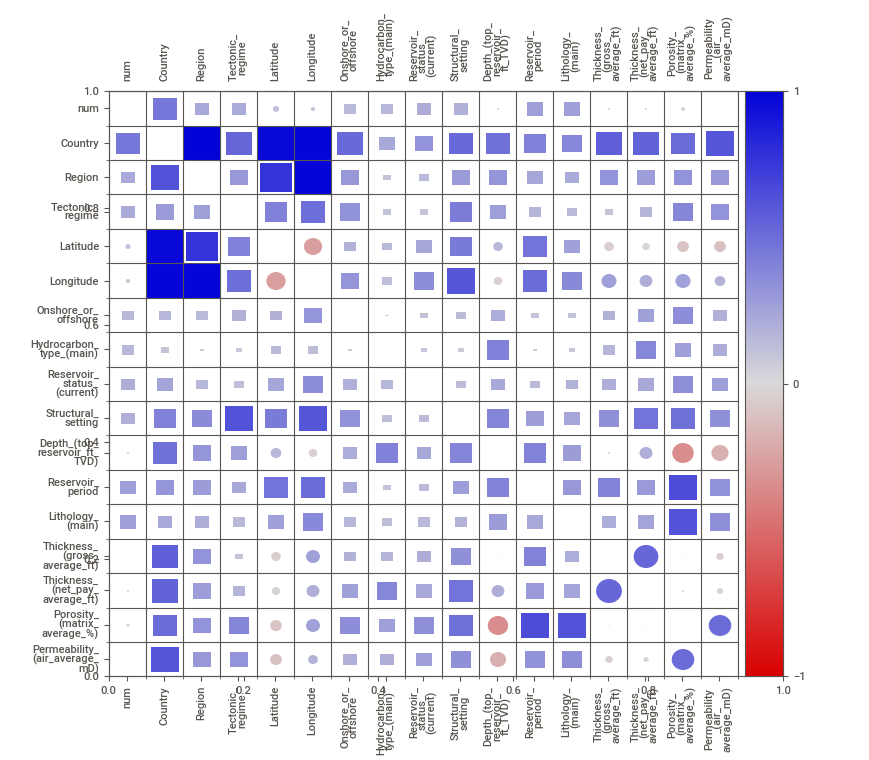
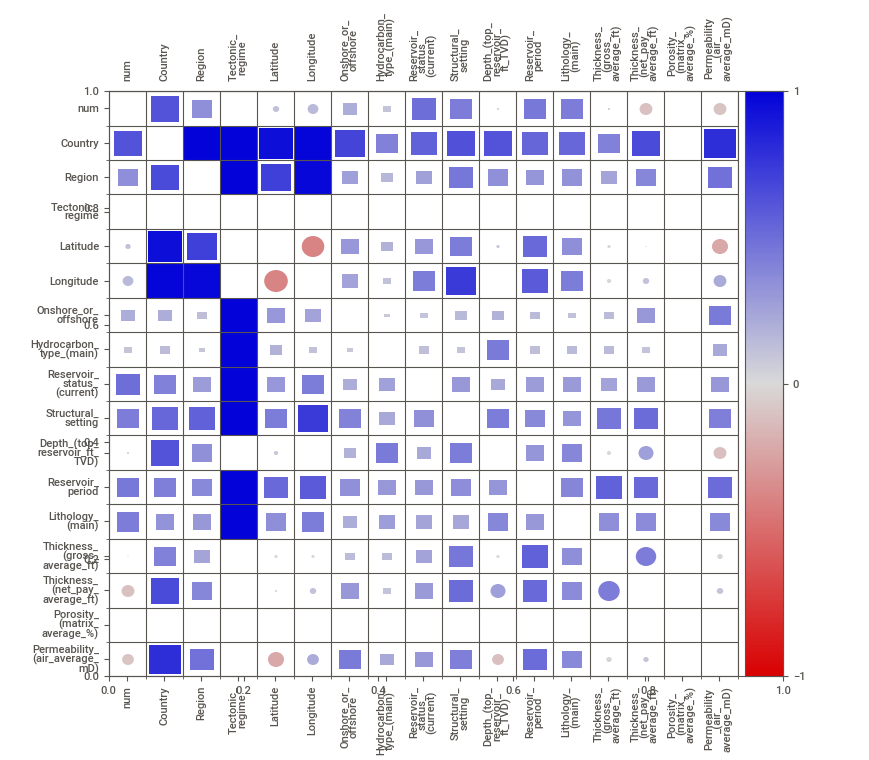

In [ ]:
comparison.show_notebook()

In [ ]:
comparison.show_html(filepath='eda_report.html', open_browser=True, layout='widescreen', scale=None)

Report eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
